<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Сегментация изображений</b></h3>


В этом задании вам предстоит решить задачу сегментации медицинских снимков. Домашнее задание можно разделить на следующие части:

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]
* Мир других лоссов! [2]
  * Dice Loss [1]
  * Focal Loss [1]
  * BONUS: лосс из статьи [5]
* Новая модель! [2]
  * UNet [2]


**Максимальный балл:** 10 баллов.

Также для студентов желающих еще более углубиться в задачу предлагается решить бонусное задание, которое даст дополнительные 5 баллов. BONUS задание необязательное.


# Шаг 1. Загрузка и подготовка данных

1. Для начала мы скачаем датасет: [ADDI project](https://www.fc.up.pt/addi/ph2%20database.html).

<table><tr><td>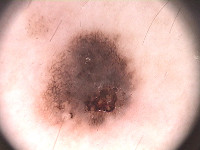</td><td>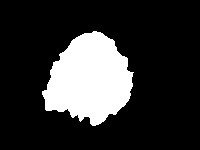</td></tr></table>

2. Разархивируем .rar файл.
3. Обратите внимание, что папка  `PH2 Dataset images` должна лежать там же где и ipynb notebook.

Это фотографии двух типов **поражений кожи:** меланома и родинки.
В данном задании мы не будем заниматься их классификацией, а будем **сегментировать** их.

In [1]:
# !gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql

In [2]:
# get_ipython().system_raw("unrar x PH2Dataset.rar")

Стуктура датасета у нас следующая:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)

In [3]:
images = []
lesions = []
from skimage.io import imread
import os
root = 'PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

Изображения имеют разные размеры. Давайте изменим их размер на $256\times256 $ пикселей. Для изменения размера изображений можно использовать [`skimage.transform.resize()`](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize).
Эта функция также автоматически нормализует изображения в диапазоне $[0,1]$.


In [4]:
from skimage.transform import resize

size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False, order=0, preserve_range=True) > 0.5 for y in lesions]



In [5]:
import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


Чтобы убедиться, что все корректно, мы нарисуем несколько изображений

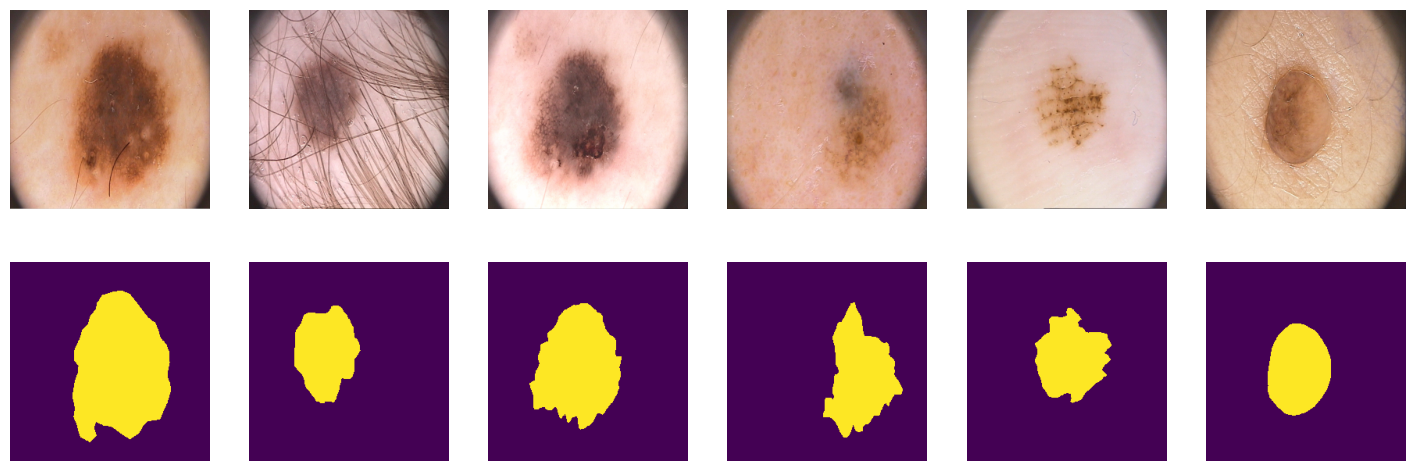

In [6]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show();

Разделим наши 200 картинок на ~~100/50/50~~ 160/20/20 (100 маловато для обучения)
 для обучения, валидации и теста соответственно

In [7]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [160, 180])

In [8]:
print(len(tr), len(val), len(ts))

160 20 20


## PyTorch DataLoader

In [9]:
from torch.utils.data import DataLoader
batch_size = 25
train_dataloader = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),
                     batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])),
                      batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])),
                     batch_size=batch_size, shuffle=False)

In [10]:
import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(DEVICE)

cuda


# Шаг 2. Метрика качества модели

## IoU (intersection over union)

В данном разделе предлагается использовать следующую метрику для оценки качества:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.


Что будет являться пересением и объединением в задаче сегментации?

Давайте разберем следующий пример:





![](https://drive.google.com/uc?export=view&id=1rBYFgli48AUUN9idiyq8j3J5DboB93yN)

In [11]:
# !pip install torchmetrics

In [12]:
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(DEVICE)

# Задания: Построй свой первый бейзлайн!

Итак, загрузка файлов, код датасета и даталоадера написана за вас. Метрика IoU написана за вас! Вам остается написать лосс, модель и функции обучения и теста модели.

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]

## Шаг 3. Loss функция - BCE [2 балла]

Популярным лоссом для бинарной сегментации является *бинарная кросс-энтропия*, которая задается следующим образом:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

где $y$ это  таргет желаемого результата и $\hat y$ является выходом модели. $\sigma$ - это [*логистическая* функция](https://en.wikipedia.org/wiki/Sigmoid_function), который преобразует действительное число $\mathbb R$ в вероятность $[0,1]$.

Однако эта потеря страдает от проблем численной нестабильности. Самое главное, что $\lim_{x\rightarrow0}\log(x)=\infty$ приводит к неустойчивости в процессе оптимизации. Рекомендуется посмотреть следующее [упрощение](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits). Эта функция эквивалентна первой и не так подвержена численной неустойчивости:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

### Вывод численно стабильной формулы BCE лосса [1 балл]



Выведите из формулы [1] формулу [2]:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

Не забываем, что здесь $\hat y_i$ - это логиты сети, не вероятности и не лейблы.

**Ответ:** 

По сути, по ссылке https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits уже написан вывод одного из другого, но с другими обозначениями. 

Знак суммы убираем, переписав выражение в векторном виде:

$y \cdot -\log(\sigma(\hat y)) + (1 - y)\cdot -\log(1 - \sigma(\hat y))$

Раскрываем сигмоиду:

$y \cdot -\log\left(\frac{1}{1 + e^{-\hat y}}\right)+ (1 - y)\cdot -\log\left(\frac{e^{-\hat y}}{1 + e^{-\hat y}}\right)$

Играем со свойствами логарифма и избавляемся от дробей и минусов:

$y \cdot \log(1 + e^{-\hat y})+ (1 - y)\cdot\left(-\log(e^{-\hat y}) + \log(1 + e^{-\hat y})\right)$

Раскрываем тривиальный логарифм от экспоненты:

$y \cdot \log(1 + e^{-\hat y})+ (1 - y)\cdot\left(\hat y + \log(1 + e^{-\hat y})\right)$

Раскрываем скобки и сокращаем множитель у логарифмов, остается 1 штука логарифма:

$(1 - y)\hat y + \log(1 + e^{-\hat y})$

И еще раз раскрываем скобки:

$\hat y - \hat y y + \log(1 + e^{-\hat y})$

### Реализуйте в коде оба варианта лосса [1 балл]

Реализуйте следующие функции:

*   `bce_true()` - честная прямая реализация лосса с формулой $$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$
*   `bce_loss()` - реализация формулы, которую мы вывели $$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right).$$

И сравните результаты функций с реализацией Pytorch:
*   `bce_torch()`
*   `bce_torch_with_logits()`

In [13]:
import torch.nn.functional as F
import torch.nn as nn

In [14]:
bce_torch = nn.BCELoss(reduction='sum') # (sigmoid(y_pred), y_real)
bce_torch_with_logits = nn.BCEWithLogitsLoss(reduction='sum')

Еще раз формулы, чтобы глазами не бегать выше:

$y \cdot -\log(\sigma(\hat y)) + (1 - y)\cdot -\log(1 - \sigma(\hat y))$

$(1 - y)\hat y + \log(1 + e^{-\hat y})$

In [15]:
def bce_loss(y_pred, y_real):
    eps = 1e-12
    y_pred = 1 / (1 + np.exp(-y_pred))  # sigmoid
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -(y_real * np.log(y_pred) + (1 - y_real) * np.log(1 - y_pred)).sum()

def bce_true(y_pred, y_real):
  return ((1 - y_real) * y_pred + np.log(1 + np.exp(-y_pred))).sum()

Проверим корректность работы на простом примере

In [16]:
y_pred = torch.randn(3, 2, requires_grad=False)
y_true = torch.rand(3, 2, requires_grad=False)

print(f'BCE loss from scratch            = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный      = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch              = {bce_torch(torch.sigmoid(y_pred), y_true)}')
print(f'BCE loss from torch with logits  = {bce_torch_with_logits(y_pred, y_true)}')


BCE loss from scratch            = 5.717121124267578
BCE loss честно посчитанный      = 5.717121601104736
BCE loss from torch              = 5.717121124267578
BCE loss from torch with logits  = 5.717121601104736


C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_19492\1101402669.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_pred = 1 / (1 + np.exp(-y_pred))  # sigmoid
C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_19492\1101402669.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return -(y_real * np.log(y_pred) + (1 - y_real) * np.log(1 - y_pred)).sum()
C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_19492\1101402669.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return ((1 - y_real) * y_pred + np.log(1 + np.exp(-y_pred))).sum()


Инструкции `assert` в Python — это булевы выражения, которые проверяют, является ли условие истинным (`True`). Внизу в коде мы проверяем функция `bce_loss()` выдает тот же результат, что и функция из Pytorch или нет. Если равенства не будет, что будет означать, что результаты функций не совпадают, а значит вы неправильно реализовали фукнцию `bce_loss()`, `assert` возвратит ошибку.

Функция `numpy.isclose()` используется для сравнения двух чисел с учётом допустимой погрешности. Она особенно полезна при работе с числами с плавающей точкой, где точное сравнение может быть проблематичным из-за ограничений представления таких чисел в компьютере.

Как она работает?

`numpy.isclose(a, b, rtol=1e-05, atol=1e-08) `принимает два числа (`a` и `b`) и сравнивает их, учитывая относительную и абсолютную погрешность. Если разница между двумя числами меньше заданного порога, функция возвращает `True`, иначе — `False`.

Параметры:

    rtol: Относительная погрешность (по умолчанию 1e-05). Используется для определения разницы относительно большего значения.
    atol: Абсолютная погрешность (по умолчанию 1e-08). Определяет минимальную разницу, которую следует учитывать.

Мы будем использовать `assert` и `numpy.isclose()` для проверки корректности нашего кода.

In [17]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))

C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_19492\1101402669.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_pred = 1 / (1 + np.exp(-y_pred))  # sigmoid
C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_19492\1101402669.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return -(y_real * np.log(y_pred) + (1 - y_real) * np.log(1 - y_pred)).sum()
C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_19492\1101402669.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return ((1 - y_real) * y_pred + np.log(1 + np.exp(-y_pred))).sum()


Давайте теперь посчитаем на простом примере, но с теми же размерностями, что и в датасете

In [18]:
y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)
y_true = torch.randint(0, 2, (2, 1, 3, 3))

print(f'BCE loss from scratch bce_loss            = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный               = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch             = {bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float))}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true.to(torch.float))}')

BCE loss from scratch bce_loss            = 10.045473098754883
BCE loss честно посчитанный               = 10.04547119140625
BCE loss from torch bce_torch             = 10.04547119140625
BCE loss from torch with logits bce_torch = 10.045472145080566


C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_19492\1101402669.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_pred = 1 / (1 + np.exp(-y_pred))  # sigmoid
C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_19492\1101402669.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return -(y_real * np.log(y_pred) + (1 - y_real) * np.log(1 - y_pred)).sum()
C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_19492\1101402669.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return ((1 - y_real) * y_pred + np.log(1 + np.exp(-y_pred))).sum()


In [19]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))

C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_19492\1101402669.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_pred = 1 / (1 + np.exp(-y_pred))  # sigmoid
C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_19492\1101402669.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return -(y_real * np.log(y_pred) + (1 - y_real) * np.log(1 - y_pred)).sum()
C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_19492\1101402669.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return ((1 - y_real) * y_pred + np.log(1 + np.exp(-y_pred))).sum()


Давайте посчитаем на реальных логитах и сегментационной маске:

In [20]:
# !gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M

In [21]:
path_to_dummy_samples = './for_asserts'
dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
                 'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')}
dummpy_sample['labels'] = dummpy_sample['labels'].to(DEVICE)
dummpy_sample['logits'] = dummpy_sample['logits'].to(DEVICE)

C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_19492\3484867643.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dummpy_sample = {'logits': torch.load(f'{path_to_dum

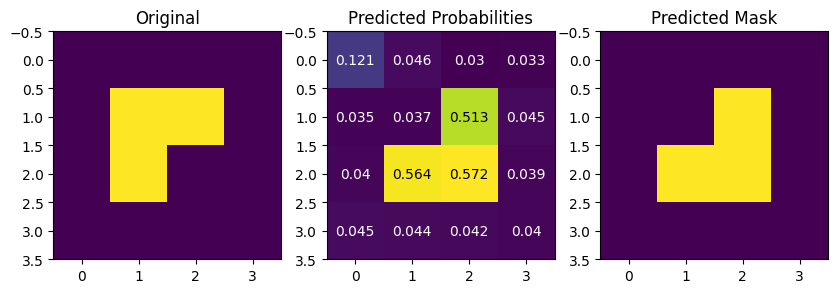

In [22]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize= (10,3*10))

ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())
for (j,i),label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    ax2.text(i,j,round(label,3), color=color, ha='center',va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")
plt.show()

Проверяем на данном примере:

In [23]:
bce_torch_score = bce_torch(torch.sigmoid(dummpy_sample['logits'].cpu()), dummpy_sample['labels'].cpu().float())
bce_torch_with_logits_score = bce_torch_with_logits(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu().float())
bce_loss_score = bce_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_true_score = bce_true(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
assert np.isclose(bce_loss_score, bce_torch_score)
assert np.isclose(bce_loss_score, bce_torch_with_logits_score)
assert np.isclose(bce_true_score, bce_torch_score)
assert np.isclose(bce_true_score, bce_torch_with_logits_score)

C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_19492\1101402669.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_pred = 1 / (1 + np.exp(-y_pred))  # sigmoid
C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_19492\1101402669.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return -(y_real * np.log(y_pred) + (1 - y_real) * np.log(1 - y_pred)).sum()
C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_19492\1101402669.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return ((1 - y_real) * y_pred + np.log(1 + np.exp(-y_pred))).sum()


## Шаг 4. Модель SegNet [2 балла]

Ваше задание здесь состоит в том, чтобы реализовать SegNet архитектуру.

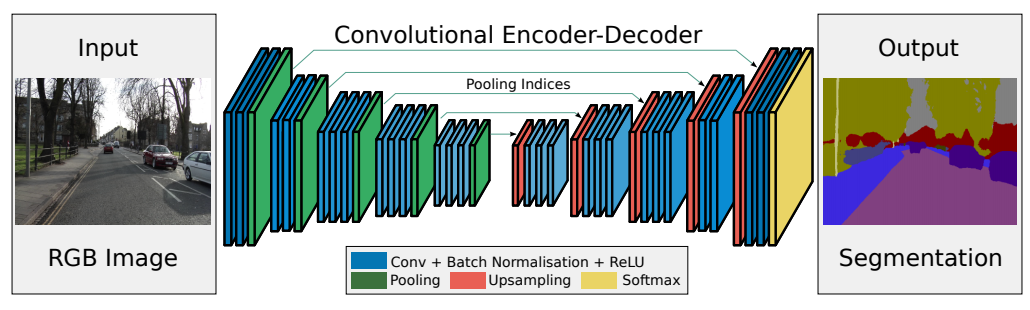

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams
rcParams['figure.figsize'] = (15,4)

Внимательно посмотрите из чего состоит модель и для чего выбраны те или иные блоки. Для этого скачаем и изучим feature extractor VGG-16, который лежит в основе SegNet.

In [25]:
# model_vgg16 = models.vgg16(weights = models.VGG16_Weights.IMAGENET1K_V1)

In [26]:
# model_vgg16

Feature extractor VGG-16 состоит из 5 блоков:
- два блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d
- три блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d

В первом блоке - на входе три канала (по числу каналов в изображениях), которые конволюционный слой преобразует в 64 канала.

Во втором, третьем и четвертом блоках первый конволюционный слой удваивает количество каналов, а последующие конволюционные слои не меняют количество каналов.

В последнем блоке число каналов от слоя к слою не меняется.

Теперь напишем код одного блока энкодера нашей модели SegNet.  

In [27]:
# Параметрами блока будут:
# - количество каналов на входе
# - количество каналов на выходе
# - глубина блока (2 или 3, по количеству конволюционных слоев)
# - kernel_size и padding
#
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super(EncoderBlock, self).__init__()
        self.layers = nn.ModuleList()

        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.maxpooling = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) #добавляем MaxPool с индексами для последующего Unpooling

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x, indices = self.maxpooling(x)
        return x, indices


По аналогии напишите код одного блока декодера.

К карте признаков на входе каждого блока примеяется nn.MaxUnpool2d с индексами из симметричного блока энкодера. Затем повторяется связка Conv + Batch Normalization + ReLU. Количество каналов меняется зеркально блокам энкодера:
- в первом блоке декодера количество каналов не меняется
- во 2-4 блоках декодера количество каналов уменьшается в 2 раза после прохождения последнего конволюционного слоя
- на выходе из последнего блока декодера 1 канал

Обратите внимание, что после последней конволюции последнего блока декодера не применяется батч-нормализация и функция активации.

In [28]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1, tail_activation = True, reduce_channels_at='tail'):
        super(DecoderBlock, self).__init__() 
        
        if reduce_channels_at not in ('head', 'tail'):
            raise ValueError(f"reduce_channels_at should be 'head' or 'tail', got: {reduce_channels_at}")
        
        self.upsampling = nn.MaxUnpool2d(kernel_size=2, stride=2)
        
        self.layers = nn.ModuleList()

        curr_channels = in_channels
        if reduce_channels_at == 'head':
            self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            curr_channels = out_channels
            self.layers.append(nn.BatchNorm2d(curr_channels))
            self.layers.append(nn.ReLU(inplace=True))

        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = curr_channels, out_channels = curr_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(curr_channels))
            self.layers.append(nn.ReLU(inplace=True))

        if reduce_channels_at == 'tail':
            self.layers.append(nn.Conv2d(in_channels = curr_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        if not tail_activation:
            del self.layers[-2:]

    def forward(self, x, max_indices):
        x = self.upsampling(x, max_indices)
        
        for layer in self.layers:
            x = layer(x)
        
        return x

Соединим блоки энкодера и декодера в модель SegNet:

In [29]:
class SegNet(nn.Module):
    def __init__(self, in_channels=3, out_channels = 1, num_features = 64) -> None:
        super(SegNet, self).__init__()

        self.encoders = nn.ModuleList([
            EncoderBlock(in_channels, num_features, depth=2),
            EncoderBlock(num_features, num_features * 2, depth=2),
            EncoderBlock(num_features * 2, num_features * 4, depth=3),
            EncoderBlock(num_features * 4, num_features * 8, depth=3),
            EncoderBlock(num_features * 8, num_features * 8, depth=3) # Encoder bottleneck - количество каналов на входе и на выходе одинаково
        ])

        self.decoders = nn.ModuleList([
            DecoderBlock(num_features * 8, num_features * 8, depth=3), # Decoder bottleneck
            DecoderBlock(num_features * 8, num_features * 4, depth=3),
            DecoderBlock(num_features * 4, num_features * 2, depth=3),
            DecoderBlock(num_features * 2, num_features, depth=2),
            DecoderBlock(num_features, out_channels, depth=2, tail_activation=False)
        ])


    def forward(self, x):
        max_pooling_indices = []
        for encoder in self.encoders:
            x, indices = encoder(x)
            max_pooling_indices.append(indices)

        for decoder, indices in zip(self.decoders, reversed(max_pooling_indices)):
            x = decoder(x, indices)

        return x  # no activation

## Шаг 5. Тренировка модели [1 балл]

Напишите функции для обучения модели.

In [30]:
from tqdm.notebook import tqdm

In [31]:
NUM_WORKERS = 1

In [32]:
def fit_epoch(model, train_loader, criterion, optimizer):
    running_loss = 0.0
    running_corrects = 0
    processed_pixels = 0
    processed_batches = 0
    
    for inputs, labels in train_loader:
        inputs = inputs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()

        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        running_loss += loss.item()
        running_corrects += torch.sum(preds == labels.data)
        processed_pixels += labels.numel()
        processed_batches += 1

    train_loss = running_loss / processed_batches
    train_acc = running_corrects.cpu().numpy() / processed_pixels
    return train_loss, train_acc

In [33]:
def eval_epoch(model, val_loader, criterion):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    processed_pixels = 0
    processed_batches = 0

    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.no_grad():
            logits = model(inputs)
            loss = criterion(logits, labels)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

        running_loss += loss.item()
        running_corrects += torch.sum(preds == labels.data)
        processed_pixels += labels.numel()
        processed_batches += 1

    val_loss = running_loss / processed_batches
    val_acc = running_corrects.double() / processed_pixels
    return val_loss, val_acc

In [34]:
import time

In [35]:
def train(train_dataset, val_dataset, model, epochs, batch_size, criterion, optimizer=None, cb_checkpoint=None, model_name='model'):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)

    start_time = time.time()
    history = []
    log_template = "\nEpoch {ep:03d}  |  Loss T:{t_loss:0.4f} \
V:{v_loss:0.4f}  |  Accuracy T:{t_acc:0.4f}, V:{v_acc:0.4f}"

    with tqdm(desc="epoch", total=epochs) as pbar_outer:
        if optimizer is None:
            optimizer = torch.optim.Adam(model.parameters())
        else:
            pass 

        best_val_loss = 999999.9
        for epoch in range(epochs):
            train_loss, train_acc = fit_epoch(model, train_loader, criterion, optimizer)

            val_loss, val_acc = eval_epoch(model, val_loader, criterion)
            history.append((train_loss, train_acc, val_loss, val_acc))

            pbar_outer.update(1)
            tqdm.write(log_template.format(ep=epoch+1, t_loss=train_loss,\
                                           v_loss=val_loss, t_acc=train_acc, v_acc=val_acc))
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save({
                    'epoch': epoch,
                    'elapsed_time_sec': time.time() - start_time,
                    'model_state': model.state_dict(),
                    'optim_state': optimizer.state_dict(),
                    'val_loss': val_loss, 
                    'val_acc': val_acc, 
                }, f"best_{model_name}.pth")

            if (epoch + 1) % 16 == 0:
                if cb_checkpoint is not None:
                    cb_checkpoint(history)
                
                torch.save({
                    'epoch': epoch,
                    'model_state': model.state_dict(),
                    'optim_state': optimizer.state_dict(),
                    'val_acc': val_acc, 
                }, f"checkpoint_{epoch}_{model_name}.pth")

    return history

In [36]:
def plot_epoch_loss(history):
    loss, acc, val_loss, val_acc = zip(*history)

    plt.figure(figsize=(7, 4))
    plt.plot(loss, label="train_loss")
    plt.plot(val_loss, label="val_loss")
    plt.legend(loc='best')
    plt.xlabel("epochs")
    plt.ylabel("loss")
    # plt.ylim(0, 1) 
    plt.show()

Обучите модель **SegNet**. В качестве оптимайзера можно взять Adam.

In [37]:
from torch.utils.data import TensorDataset

def to_tensor_dataset(x, y):
    x_np = np.rollaxis(x, 3, 1).astype(np.float32)   # (N, C, H, W)
    y_np = y[:, np.newaxis].astype(np.float32)       # (N, 1, H, W) 

    X_t = torch.from_numpy(x_np)
    Y_t = torch.from_numpy(y_np)

    return TensorDataset(X_t, Y_t)

train_dataset = to_tensor_dataset(X[tr], Y[tr])
val_dataset = to_tensor_dataset(X[val], Y[val])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=NUM_WORKERS)

In [38]:
# Если при обучении падает по out of memory, то память сама не чистится без перезапуска ядра
# так что тут ручная зачистка для повторных запусков
import gc

def cleanup_models():
    for name, obj in list(globals().items()):
        if isinstance(obj, torch.nn.Module) and 'model' in name:
            del globals()[name]

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()


In [39]:
cleanup_models()

In [40]:
bce_mean = nn.BCEWithLogitsLoss(reduction='mean')

In [247]:
model = SegNet().to(DEVICE)

history = train(
    train_dataset=train_dataset, 
    val_dataset=val_dataset, 
    model=model, 
    epochs=128, 
    batch_size=16, 
    criterion=bce_mean,
    optimizer=torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-2), 
    cb_checkpoint=plot_epoch_loss
)

epoch:   0%|          | 0/128 [00:00<?, ?it/s]


Epoch 001  |  Loss T:0.5152 V:0.6385  |  Accuracy T:0.7660, V:0.6808

Epoch 002  |  Loss T:0.6443 V:0.6337  |  Accuracy T:0.6858, V:0.6808

Epoch 003  |  Loss T:0.5839 V:0.7048  |  Accuracy T:0.7095, V:0.4628

Epoch 004  |  Loss T:0.4736 V:0.5214  |  Accuracy T:0.7964, V:0.7664


KeyboardInterrupt: 

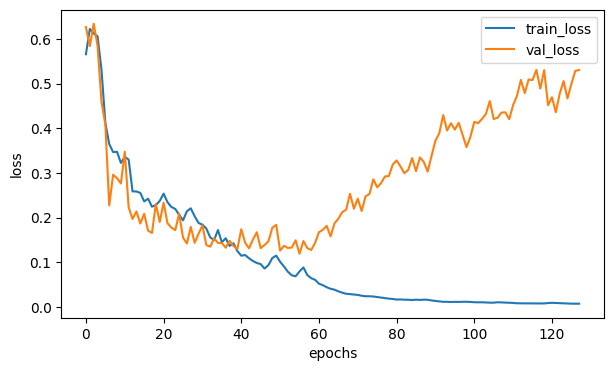

In [194]:
plot_epoch_loss(history)

## Шаг 6. Инференс [1 балл]

После обучения модели напишите функцию теста, воспользуйтесь лучшим чекпоинтом и протестируйте работу модели на тестовой выборке.

In [41]:
# del model
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
torch.cuda.synchronize()

In [42]:
test_dataset = to_tensor_dataset(X[ts], Y[ts])
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=64, num_workers=NUM_WORKERS)

In [43]:
def test(model, val_loader, criterion):
    iou_score.reset()
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    processed_pixels = 0
    processed_batches = 0

    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with torch.no_grad():
            logits = model(inputs)
            loss = criterion(logits, labels)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

        running_loss += loss.item()
        running_corrects += torch.sum(preds == labels.data)
        processed_pixels += inputs.numel()
        processed_batches += 1

        iou_score.update(preds, labels)

    avg_loss = running_loss / processed_batches
    avg_acc = running_corrects.double() / processed_pixels
    return avg_loss, avg_acc

In [71]:
def test_model_checkpoint(cp, model, criterion):
    try:
        checkpoint = torch.load(cp, map_location=DEVICE)
    except:
        print(f"No such checkpoint: {cp}")
        return

    model = model().to(DEVICE)
    model.load_state_dict(checkpoint["model_state"])

    test_loss, test_acc = test(model, test_loader, criterion=criterion)
    print(f'\n----- ----- {cp} ----- -----')
    print(f'Epoch: {checkpoint["epoch"]}')
    if "elapsed_time_sec" in checkpoint:
        print(f'Elapsed time: {checkpoint["elapsed_time_sec"]} sec.')
    print(f'Test loss: {test_loss}, test accuracy: {test_acc}')
    print(f'Test IoU: {iou_score.compute()}')

In [ ]:
cleanup_models()
test_model_checkpoint("best_model.pth", model=SegNet, criterion=bce_mean)
cleanup_models()

C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_23936\2457604070.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(cp, map_location=DEVICE)


best_model.pth epoch: 55
best_model.pth | Test loss: 0.08531504124403, test accuracy: 0.3236279805501302
best_model.pth | Test IoU: 0.9045805931091309


# Задания: Мир других лососов!

## Пробуем другие функции потерь [2 балла]

В данном разделе вам потребуется имплементировать две функции потерь: DICE и Focal loss.


### Dice Loss

**1. Dice coefficient:** Учитывая две маски $X$ и $Y$, общая метрика для измерения расстояния между этими двумя масками задается следующим образом:

$$D(X,Y)=\frac{2|X\cap Y|}{|X|+|Y|}$$

В терминах матрицы ошибок она будет считаться следующим образом:

$$D(X,Y) = \frac{2TP}{2TP + FP + FN}$$

Эта функция не является дифференцируемой, но это необходимое свойство для градиентного спуска. В данном случае мы можем приблизить его с помощью:

$$\mathcal L_D(X,Y) = 1- D(X, Y)$$

**Hints** (!):

1. Не забудьте подумать о численной нестабильности, возникающей в математической формуле при ситуации, когда $\frac{0}{0}$, т.е. вам нужно добавить очень маленькое число, например $\epsilon = 1e^{-8}$, в обе части дроби при подсчете $D(X,Y)$:

$$D(X,Y) = \frac{2TP + ϵ}{2TP + FP + FN + ϵ}$$

2. Dice метрика(!), не лосс, считается похожим образом как IoU:

    2.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    2.2. Фиксируем порог, например threshold=0.5, и всему что ниже порога ставим значение 0, всему что выше 1. Получаем предсказанную маску из 0 и 1.

    2.3. Считаем TP, FP, FN

    2.4. Считаем DICE метрику по формуле

Вы можете прописать для себя функцию `dice_score()` и сравнить с результатами работы функции из библиотеки `torchmetrics`.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

Итак, давайте сначала пропишем dice_score.

In [45]:
def dice_score(logits: torch.Tensor, labels: torch.Tensor, threshold: float = 0.5):
    probs = F.sigmoid(logits)
    preds = (probs > threshold).to(int)

    tp = ((preds == 1) & (labels == 1)).sum() / labels.size(1)
    fp = ((preds == 1) & (labels == 0)).sum() / labels.size(1)
    fn = ((preds == 0) & (labels == 1)).sum() / labels.size(1)

    eps = 1e-8
    score = (2 * tp + eps) / (2 * tp + fp + fn + eps)

    return score

Проверим на корректность функцию dice_score:

In [46]:
from torchmetrics.segmentation import DiceScore

dice = DiceScore(num_classes=1, average='micro').to(DEVICE)
dice(dummpy_sample['logits'].sigmoid() > 0.5, dummpy_sample['labels'].to(int))

c:\Users\efimplotnikov\Projects\DeepLearningSchool_part_1_ml_cv\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)


tensor(0.6667, device='cuda:0')

In [201]:
'''
если вы используете версию библиотеки 0.11.4, то можно взять torchmetrics.classification.Dice():

from torchmetrics.classification import Dice

dice = Dice(average='micro').to(DEVICE)

'''

"\nесли вы используете версию библиотеки 0.11.4, то можно взять torchmetrics.classification.Dice():\n\nfrom torchmetrics.classification import Dice\n\ndice = Dice(average='micro').to(DEVICE)\n\n"

In [47]:
dice_torch = dice(dummpy_sample['logits'].sigmoid() > 0.5, dummpy_sample['labels'].to(int))
dice_custom = dice_score(dummpy_sample['logits'], dummpy_sample['labels'].to(int))
print(dice_torch, dice_custom)
assert dice_torch == dice_custom

tensor(0.6667, device='cuda:0') tensor(0.6667, device='cuda:0')


Давайте теперь пропишем лосс и воспользуемся библиотекой `segmentation-models-pytorch`, чтобы убедиться в корректности нашей функции.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

In [48]:
def dice_loss(logits: torch.Tensor, labels: torch.Tensor):
    logits = torch.clamp(logits, -20, 20) # HACK: sigmoid is oversaturated otherwise
    probs = F.sigmoid(logits)
    probs = probs.flatten(1)
    labels = labels.flatten(1)

    tp = (probs * labels).sum(dim=1)
    fp = (probs * (1 - labels)).sum(dim=1)
    fn = ((1 - probs) * labels).sum(dim=1)

    eps = 1e-8
    score = (2 * tp + eps) / (2 * tp + fp + fn + eps)

    return 1 - score.mean()

Проверка на корректность:

In [204]:
# проверьте, что у вас установлена библиотека
#!pip install segmentation-models-pytorch

In [49]:
from segmentation_models_pytorch.losses import DiceLoss
dice_loss_torch = DiceLoss(mode='binary')
dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'])

tensor(0.5756, device='cuda:0')

In [50]:
loss_torch = dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'].to(int))
loss_custom = dice_loss(dummpy_sample['logits'], dummpy_sample['labels'])
print(loss_torch, loss_custom)
assert loss_torch == loss_custom

tensor(0.5756, device='cuda:0') tensor(0.5756, device='cuda:0')


### Focal Loss

[**2. Focal loss:**](https://arxiv.org/pdf/1708.02002.pdf)

Окей, мы уже с вами умеем делать BCE loss:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проблема с этой потерей заключается в том, что она имеет тенденцию приносить пользу классу **большинства** (фоновому) по отношению к классу **меньшинства** ( переднему). Поэтому обычно применяются весовые коэффициенты к каждому классу:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Традиционно вес $\alpha_i$ определяется как обратная частота класса этого пикселя $i$, так что наблюдения миноритарного класса весят больше по отношению к классу большинства.


Из оригинальной статьи по [Focal Loss](https://arxiv.org/pdf/1708.02002.pdf):

$$p_t = \sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)$$

$$\mathcal L_{focal}(y, \hat y) = (1 - p_t)^{\gamma} \mathcal L_{BCE}(y_i, \hat y_i).$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - p_t)^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - (\sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)))^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

In [51]:
def focal_loss(y_pred, y_real, eps = 1e-8, gamma = 2, reduction='mean'):
    prob = torch.sigmoid(y_pred)
    p_t = prob * y_real + (1 - prob) * (1 - y_real)
    bce = F.binary_cross_entropy_with_logits(y_pred, y_real, reduction="none")
    modulating_factor = (1.0 - p_t) ** gamma
    loss = modulating_factor * bce

    if reduction == 'mean':
        return loss.mean()
    elif reduction == 'sum':
        return loss.sum()
    
    return loss

Проверка корректности функции:

In [52]:
from torchvision.ops import sigmoid_focal_loss
sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='mean')

tensor(0.2260, device='cuda:0')

In [53]:
torch_focal = sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='mean')
custom_focal = focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], gamma=2.0, reduction='mean')
print(torch_focal, "\n", custom_focal)
assert torch_focal == custom_focal

tensor(0.2260, device='cuda:0') 
 tensor(0.2260, device='cuda:0')


## [BONUS] Мир сегментационных лоссов [5 баллов]

В данном блоке предлагаем вам написать одну функцию потерь самостоятельно. Для этого необходимо прочитать статью и имплементировать ее, и провести численное сравнение с предыдущими функциями.

* [Physiological Inspired Deep Neural Networks for Emotion Recognition](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=8472816&tag=1)". IEEE Access, 6, 53930-53943.

* [Boundary loss for highly unbalanced segmentation](https://arxiv.org/abs/1812.07032)

* [Tversky loss function for image segmentation using 3D fully convolutional deep networks](https://arxiv.org/abs/1706.05721)

* [Correlation Maximized Structural Similarity Loss for Semantic Segmentation](https://arxiv.org/abs/1910.08711)

* [Topology-Preserving Deep Image Segmentation](https://papers.nips.cc/paper/8803-topology-preserving-deep-image-segmentation)

In [210]:
# TODO

## Обучите SegNet на новых лоссах

**Задание**: обучите SegNet на новых лоссах и сравните все три лосса:
*   При каком лоссе модель сходится быстрее?
*   При каком лоссе модель выдает наилучшую метрику?

Напишите развернутый ответ на вопросы.



epoch:   0%|          | 0/128 [00:00<?, ?it/s]

labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.17432594299316406
logits mean/std, probs mean: 0.33668965101242065 0.40526047348976135 0.5792405605316162
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.4126777648925781
logits mean/std, probs mean: 0.26443830132484436 1.0362271070480347 0.5332930684089661
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.25015830993652344
logits mean/std, probs mean: 0.3503172993659973 1.249298334121704 0.5413979291915894
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.3381767272949219
logits mean/std, probs mean: 0.5943871736526489 1.1755589246749878 0.5964266657829285
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.4151496887207031
logits mean/std, probs mean: 0.7102841734886169 1.0969784259796143 0.6268668174743652
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.24020767211914062
logits mean/std, probs mean: 0.8249508142471313 1.0369057655334473 0.6551575660705566
labels dtype/min/max/un

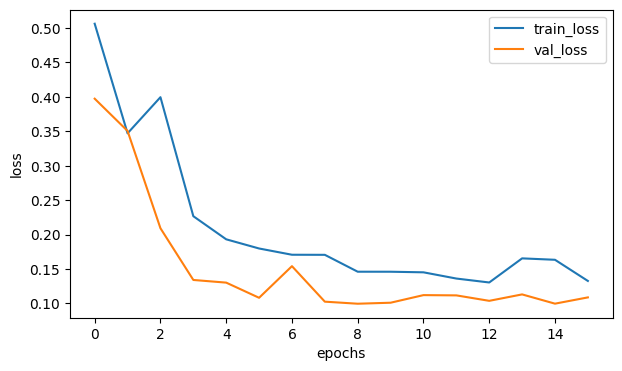

labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.40619850158691406
logits mean/std, probs mean: 1576.31298828125 3424.38818359375 0.3963012397289276
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.35137367248535156
logits mean/std, probs mean: 1844.718505859375 4596.3271484375 0.3355182409286499
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.36163902282714844
logits mean/std, probs mean: 2173.60400390625 5084.1611328125 0.36497581005096436
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.2459869384765625
logits mean/std, probs mean: 2103.01904296875 7178.59521484375 0.2104732096195221
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.39122962951660156
logits mean/std, probs mean: 5063.609375 13260.0888671875 0.37818530201911926
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.27455902099609375
logits mean/std, probs mean: 3097.429443359375 10154.232421875 0.3507777452468872
labels dtype/min/max/unique_ratio: torch.float32 0.

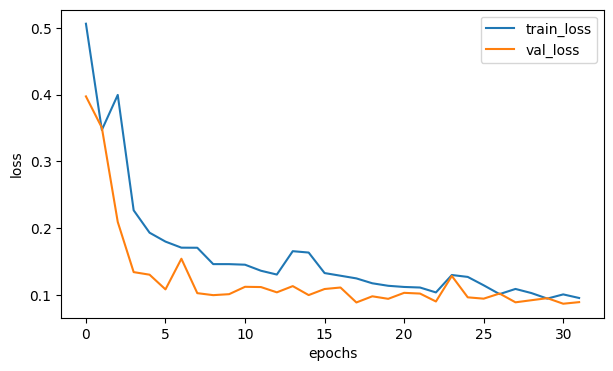

labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.4864006042480469
logits mean/std, probs mean: 4279.9267578125 15721.8896484375 0.4441225826740265
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.2809734344482422
logits mean/std, probs mean: 5360.2021484375 16275.9423828125 0.2718474268913269
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.32966041564941406
logits mean/std, probs mean: 5781.2158203125 21576.111328125 0.3468344211578369
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.3137836456298828
logits mean/std, probs mean: 3556.242431640625 12239.609375 0.29424530267715454
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.2535858154296875
logits mean/std, probs mean: 2896.642578125 10017.623046875 0.2503502666950226
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.4111480712890625
logits mean/std, probs mean: 3354.9931640625 8685.4208984375 0.3859177231788635
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.387

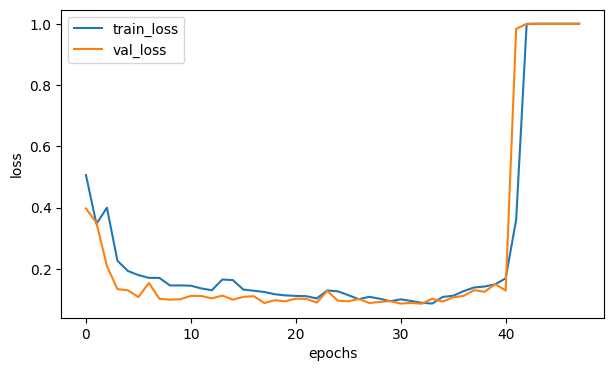

labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.25835227966308594
logits mean/std, probs mean: -619561728.0 402128064.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.2535419464111328
logits mean/std, probs mean: -568087616.0 357084640.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.32938575744628906
logits mean/std, probs mean: -616993536.0 391941568.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.30036163330078125
logits mean/std, probs mean: -567144128.0 349998208.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.3921375274658203
logits mean/std, probs mean: -674961472.0 424843424.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.3475666046142578
logits mean/std, probs mean: -592064000.0 378494176.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.3600139617919922
logits mean/std, probs mean: -618308096.0 390198144.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.

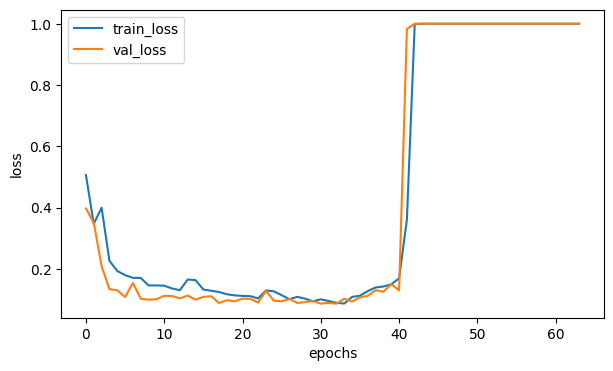

labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.19125938415527344
logits mean/std, probs mean: -571007744.0 338711552.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.34354400634765625
logits mean/std, probs mean: -530409376.0 331391840.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.4505634307861328
logits mean/std, probs mean: -617346496.0 395312320.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.30536460876464844
logits mean/std, probs mean: -547824192.0 322889760.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.4170074462890625
logits mean/std, probs mean: -604829184.0 381529632.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.3047447204589844
logits mean/std, probs mean: -529637536.0 336387584.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.15607261657714844
logits mean/std, probs mean: -526481760.0 304459744.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0

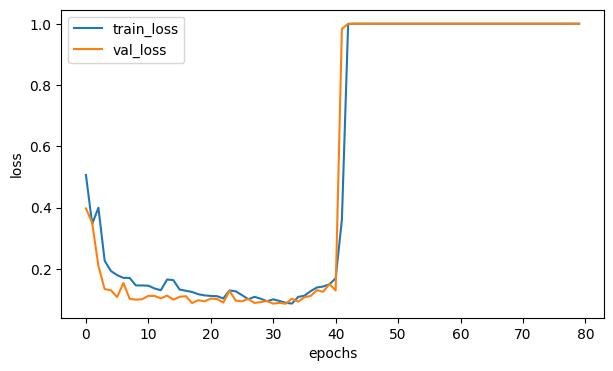

labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.3686256408691406
logits mean/std, probs mean: -534326240.0 320285984.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.20607757568359375
logits mean/std, probs mean: -522183328.0 318577888.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.39789772033691406
logits mean/std, probs mean: -526155296.0 339222720.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.18097686767578125
logits mean/std, probs mean: -478310592.0 291441664.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.34653282165527344
logits mean/std, probs mean: -525205056.0 318379808.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.22749900817871094
logits mean/std, probs mean: -458850848.0 294497760.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.2760124206542969
logits mean/std, probs mean: -515443136.0 305642368.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 

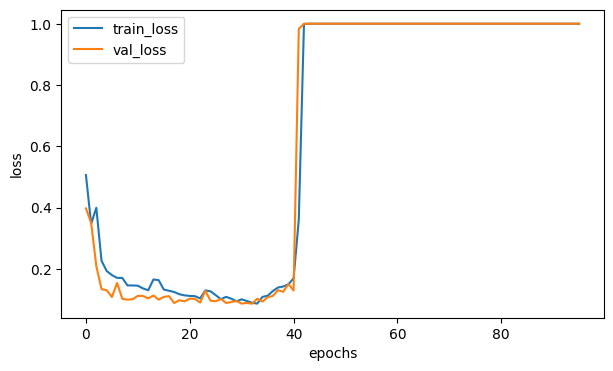

labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.2601203918457031
logits mean/std, probs mean: -478071200.0 295902720.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.3287162780761719
logits mean/std, probs mean: -452086784.0 278503136.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.25553131103515625
logits mean/std, probs mean: -439576128.0 268828256.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.22599411010742188
logits mean/std, probs mean: -438791360.0 266028032.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.3209190368652344
logits mean/std, probs mean: -486936960.0 288122880.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.36768150329589844
logits mean/std, probs mean: -490139648.0 314085696.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.32407188415527344
logits mean/std, probs mean: -505485376.0 314449312.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0

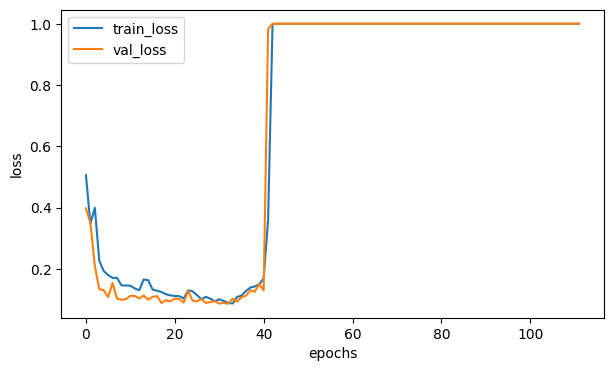

labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.27485084533691406
logits mean/std, probs mean: -464640000.0 287680512.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.3387718200683594
logits mean/std, probs mean: -439439968.0 271806688.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.4427661895751953
logits mean/std, probs mean: -487111328.0 300402240.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.32419586181640625
logits mean/std, probs mean: -433434880.0 269159296.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.15717315673828125
logits mean/std, probs mean: -416603456.0 269375904.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.30495452880859375
logits mean/std, probs mean: -423270496.0 264744752.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0.3488349914550781
logits mean/std, probs mean: -511117792.0 320325728.0 0.0
labels dtype/min/max/unique_ratio: torch.float32 0.0 1.0 0

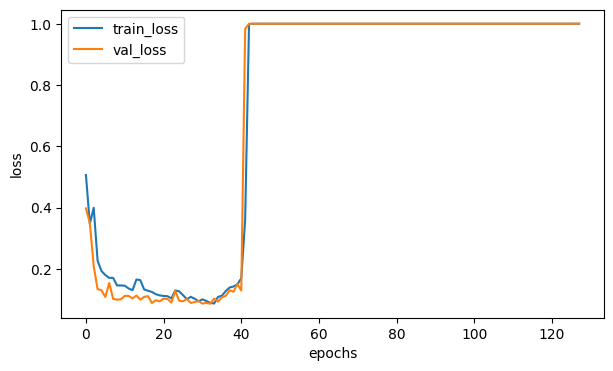

In [237]:
dice_model = SegNet().to(DEVICE)

history_dice = train(
    train_dataset=train_dataset, 
    val_dataset=val_dataset, 
    model=dice_model, 
    model_name='dice_model',
    epochs=128, 
    batch_size=8, 
    criterion=dice_loss,
    optimizer=torch.optim.AdamW(dice_model.parameters(), lr=5e-4, weight_decay=1e-2), 
    cb_checkpoint=plot_epoch_loss
)

In [ ]:
test_model_checkpoint("best_dice_model.pth", model=SegNet, criterion=dice_loss)
cleanup_models()

C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_23936\2457604070.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(cp, map_location=DEVICE)


best_dice_model.pth epoch: 32
best_dice_model.pth | Test loss: 0.0673227310180664, test accuracy: 0.32002436319986977
best_dice_model.pth | Test IoU: 0.8713769316673279


In [245]:
cleanup_models()
focal_model = SegNet().to(DEVICE)

history_focal = train(
    train_dataset=train_dataset, 
    val_dataset=val_dataset, 
    model=focal_model, 
    model_name='focal_model',
    epochs=128, 
    batch_size=8, 
    criterion=focal_loss,
    optimizer=torch.optim.AdamW(focal_model.parameters(), lr=5e-4, weight_decay=1e-2), 
    cb_checkpoint=plot_epoch_loss 
)

TypeError: ModuleList.pop() missing 1 required positional argument: 'key'

In [ ]:
test_model_checkpoint("best_focal_model.pth", model=SegNet, criterion=focal_loss)

C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_23936\2457604070.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(cp, map_location=DEVICE)


best_focal_model.pth epoch: 94
best_focal_model.pth | Test loss: 0.017077263444662094, test accuracy: 0.3247904459635417
best_focal_model.pth | Test IoU: 0.9157808423042297


### Ответы

---

# Задание: Новая модель!

## Модель U-Net [2 балла]

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.

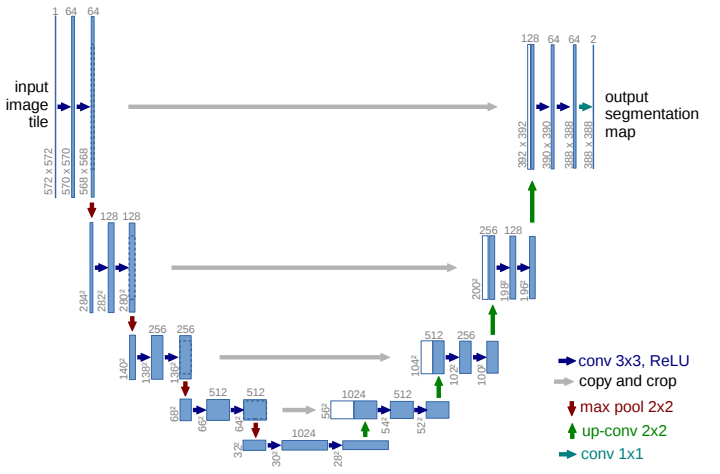

У нас в архитектуре все так же существует энкодер и декодер, как в **SegNet**, но отличительной особеностью данной модели являются *skip-conenctions*, соединяющие части декодера и энкодера. То есть для того чтобы передать на вход декодера тензор, мы конкатенируем симметричный выход с энкодера и выход предыдущего слоя декодера.

* Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "[U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)" International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.

В оригинальной статье авторы не использовали padding внутри модели (это видно по тому, что размеры карты признаков уменьшаются на 2 каждый раз при движении от слоя к слою). При этом размеры входных изображений авторы единоразово увеличили при помощи mirror padding.

В этом домашнем задании вы можете применить альтернативный подход - сохранять размеры карт признаков при помощью padding = 1 во внутренних слоях.  

In [54]:
import torch.nn.functional as F
import torch.nn as nn

Для реализации UNet вы можете написать классы блоков энкодера и декодера отдельно, как мы сделали при реализации SegNet.

---

Для более честного сравнения архитектур, будем использовать то же количество блоков и слоёв в них

In [55]:
class UEncoderBlock(EncoderBlock):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1, bottleneck = False):
        super(UEncoderBlock, self).__init__(in_channels, out_channels, depth, kernel_size, padding)

        if bottleneck:
            self.maxpooling = None

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        
        x_skip = x

        if self.maxpooling is None:
            return x, None, None  # no pooling in bottleneck 

        x, indices = self.maxpooling(x)
        return x, x_skip, indices


class UDecoderBlock(DecoderBlock):

    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1, tail_activation = True, reduce_channels_at='head'):
        super(UDecoderBlock, self).__init__(in_channels, out_channels, depth, kernel_size, padding, tail_activation, reduce_channels_at) 

    def forward(self, x, x_skip, max_indices):
        x = self.upsampling(x, max_indices)
        x = torch.cat([x, x_skip], dim=1)  # add skip connections

        for layer in self.layers:
            x = layer(x)
        
        return x


class UNet(nn.Module):
    def __init__(self, n_class=1, in_channels=3, num_features = 64):
        super(UNet, self).__init__()

        self.in_conv = nn.Conv2d(in_channels=in_channels, out_channels=num_features, kernel_size=1)

        self.encoders = nn.ModuleList([
            UEncoderBlock(num_features,     num_features * 2,  depth=2),
            UEncoderBlock(num_features * 2, num_features * 4,  depth=2),
            UEncoderBlock(num_features * 4, num_features * 8,  depth=3),
            UEncoderBlock(num_features * 8, num_features * 16, depth=3),
        ])

        self.bottleneck = UEncoderBlock(num_features * 16, num_features * 16, depth=3, bottleneck=True)

        self.decoders = nn.ModuleList([            
            UDecoderBlock(num_features * (16*2), num_features * 8, depth=3),
            UDecoderBlock(num_features * (8*2),  num_features * 4,  depth=3),
            UDecoderBlock(num_features * (4*2),  num_features * 2,  depth=2),
            UDecoderBlock(num_features * (2*2),  num_features,      depth=2),
        ])

        self.out_conv = nn.Conv2d(in_channels=64, out_channels=n_class, kernel_size=1)


    def forward(self, x):
        x = self.in_conv(x)

        max_pooling_indices = []
        x_skips = []
        for encoder in self.encoders:
            x, x_skip, indices = encoder(x)
            x_skips.append(x_skip)
            max_pooling_indices.append(indices)

        x, _, _ = self.bottleneck(x)

        for decoder, indices, skip in zip(self.decoders, reversed(max_pooling_indices), reversed(x_skips)):
            x = decoder(x, x_skip=skip, max_indices=indices)

        return self.out_conv(x)

## Обучите UNet

Задание: обучите UNet на всех трех лоссах: BCE, Dice, Focal и сравните результаты с SegNet:
*   Какая модель дает лучшие значения по метрике?
*   Какая модель дает лучшие значения по лоссам?
*   Какая модель обучается быстрее?
*   Сравните визуально результаты SegNet и UNet.

Напишите развернутый ответ на вопросы.



epoch:   0%|          | 0/128 [00:00<?, ?it/s]


Epoch 001  |  Loss T:0.4355 V:5.9442  |  Accuracy T:0.8221, V:0.4965

Epoch 002  |  Loss T:0.7283 V:0.3936  |  Accuracy T:0.7339, V:0.8218

Epoch 003  |  Loss T:0.4402 V:0.3717  |  Accuracy T:0.7941, V:0.8443

Epoch 004  |  Loss T:0.4155 V:0.3630  |  Accuracy T:0.8083, V:0.8579

Epoch 005  |  Loss T:0.4117 V:0.3552  |  Accuracy T:0.8195, V:0.8407

Epoch 006  |  Loss T:0.3977 V:0.3092  |  Accuracy T:0.8258, V:0.8769

Epoch 007  |  Loss T:0.3611 V:0.2773  |  Accuracy T:0.8445, V:0.8871

Epoch 008  |  Loss T:0.3537 V:0.2965  |  Accuracy T:0.8476, V:0.8725

Epoch 009  |  Loss T:0.3261 V:0.2615  |  Accuracy T:0.8664, V:0.8923

Epoch 010  |  Loss T:0.3729 V:0.3729  |  Accuracy T:0.8440, V:0.8964

Epoch 011  |  Loss T:0.4106 V:0.3853  |  Accuracy T:0.8597, V:0.8398

Epoch 012  |  Loss T:0.4249 V:0.2519  |  Accuracy T:0.8119, V:0.9035

Epoch 013  |  Loss T:0.3377 V:0.3281  |  Accuracy T:0.8638, V:0.8586

Epoch 014  |  Loss T:0.3522 V:0.3219  |  Accuracy T:0.8437, V:0.8675

Epoch 015  |  Loss 

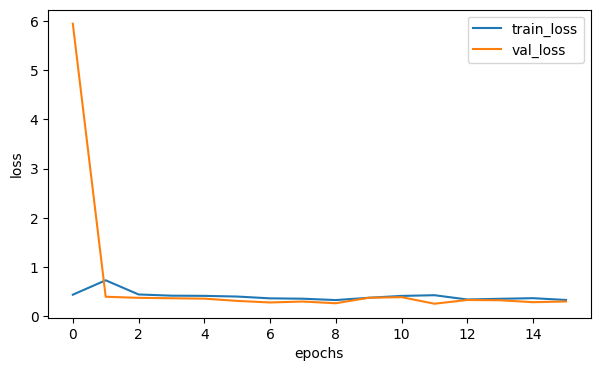


Epoch 017  |  Loss T:0.3654 V:0.3108  |  Accuracy T:0.8399, V:0.8670

Epoch 018  |  Loss T:0.3619 V:0.3140  |  Accuracy T:0.8429, V:0.8724

Epoch 019  |  Loss T:0.3739 V:0.3478  |  Accuracy T:0.8427, V:0.8488

Epoch 020  |  Loss T:0.3848 V:0.3304  |  Accuracy T:0.8361, V:0.8636

Epoch 021  |  Loss T:0.3612 V:0.3057  |  Accuracy T:0.8422, V:0.8812

Epoch 022  |  Loss T:0.3348 V:0.2790  |  Accuracy T:0.8546, V:0.8858

Epoch 023  |  Loss T:0.3112 V:0.2811  |  Accuracy T:0.8683, V:0.8871

Epoch 024  |  Loss T:0.2908 V:0.2551  |  Accuracy T:0.8777, V:0.9028

Epoch 025  |  Loss T:0.2819 V:0.3170  |  Accuracy T:0.8826, V:0.8814

Epoch 026  |  Loss T:0.2649 V:0.3111  |  Accuracy T:0.8888, V:0.8930

Epoch 027  |  Loss T:0.2856 V:0.2920  |  Accuracy T:0.8847, V:0.8976

Epoch 028  |  Loss T:0.2732 V:0.2726  |  Accuracy T:0.8891, V:0.8998

Epoch 029  |  Loss T:0.2412 V:0.2535  |  Accuracy T:0.9018, V:0.9083

Epoch 030  |  Loss T:0.2380 V:0.2049  |  Accuracy T:0.9018, V:0.9225

Epoch 031  |  Loss 

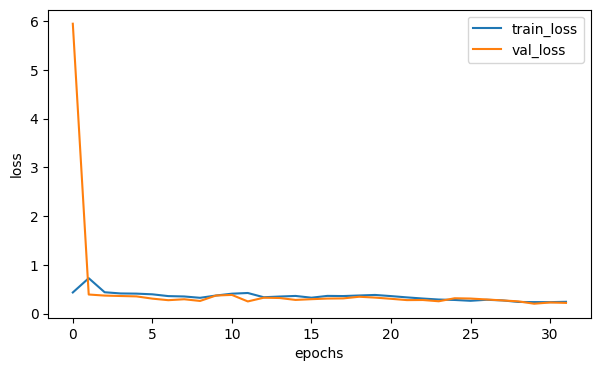


Epoch 033  |  Loss T:0.2671 V:0.2585  |  Accuracy T:0.8940, V:0.8990

Epoch 034  |  Loss T:0.2277 V:0.2332  |  Accuracy T:0.9067, V:0.9162

Epoch 035  |  Loss T:0.2168 V:0.2275  |  Accuracy T:0.9149, V:0.9202

Epoch 036  |  Loss T:0.2376 V:0.2323  |  Accuracy T:0.9058, V:0.9172

Epoch 037  |  Loss T:0.2468 V:0.2744  |  Accuracy T:0.9001, V:0.8981

Epoch 038  |  Loss T:0.2474 V:0.2195  |  Accuracy T:0.9001, V:0.9234

Epoch 039  |  Loss T:0.2300 V:0.2108  |  Accuracy T:0.9101, V:0.9270

Epoch 040  |  Loss T:0.2412 V:0.2648  |  Accuracy T:0.9071, V:0.9092

Epoch 041  |  Loss T:0.2160 V:0.1788  |  Accuracy T:0.9171, V:0.9314

Epoch 042  |  Loss T:0.2122 V:0.2100  |  Accuracy T:0.9215, V:0.9335

Epoch 043  |  Loss T:0.1966 V:0.2925  |  Accuracy T:0.9260, V:0.8790

Epoch 044  |  Loss T:0.2424 V:0.1995  |  Accuracy T:0.9021, V:0.9328

Epoch 045  |  Loss T:0.2157 V:0.2023  |  Accuracy T:0.9218, V:0.9290

Epoch 046  |  Loss T:0.1897 V:0.1861  |  Accuracy T:0.9273, V:0.9386

Epoch 047  |  Loss 

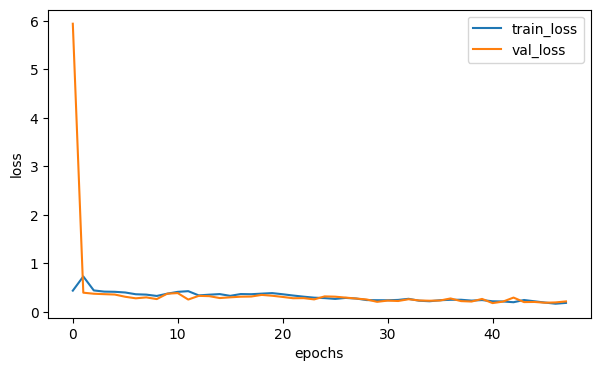


Epoch 049  |  Loss T:0.1766 V:0.2096  |  Accuracy T:0.9313, V:0.9341

Epoch 050  |  Loss T:0.1738 V:0.2042  |  Accuracy T:0.9340, V:0.9243

Epoch 051  |  Loss T:0.1895 V:0.1758  |  Accuracy T:0.9269, V:0.9418

Epoch 052  |  Loss T:0.1592 V:0.1522  |  Accuracy T:0.9377, V:0.9461

Epoch 053  |  Loss T:0.1495 V:0.1995  |  Accuracy T:0.9404, V:0.9431

Epoch 054  |  Loss T:0.1375 V:0.1762  |  Accuracy T:0.9463, V:0.9452

Epoch 055  |  Loss T:0.1557 V:0.2170  |  Accuracy T:0.9425, V:0.9310

Epoch 056  |  Loss T:0.1512 V:0.1809  |  Accuracy T:0.9413, V:0.9472

Epoch 057  |  Loss T:0.1323 V:0.1720  |  Accuracy T:0.9480, V:0.9424

Epoch 058  |  Loss T:0.1475 V:0.1500  |  Accuracy T:0.9425, V:0.9521

Epoch 059  |  Loss T:0.1440 V:0.1473  |  Accuracy T:0.9439, V:0.9524

Epoch 060  |  Loss T:0.1517 V:0.1743  |  Accuracy T:0.9424, V:0.9437

Epoch 061  |  Loss T:0.1441 V:0.1833  |  Accuracy T:0.9424, V:0.9473

Epoch 062  |  Loss T:0.1307 V:0.1867  |  Accuracy T:0.9481, V:0.9451

Epoch 063  |  Loss 

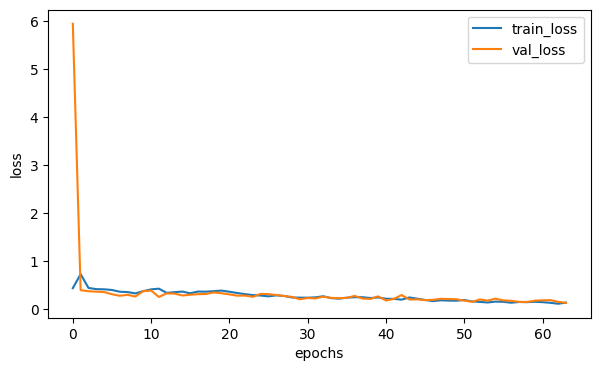


Epoch 065  |  Loss T:0.1150 V:0.1565  |  Accuracy T:0.9536, V:0.9550

Epoch 066  |  Loss T:0.1001 V:0.1490  |  Accuracy T:0.9589, V:0.9569

Epoch 067  |  Loss T:0.1360 V:0.1692  |  Accuracy T:0.9490, V:0.9510

Epoch 068  |  Loss T:0.1369 V:0.1288  |  Accuracy T:0.9471, V:0.9561

Epoch 069  |  Loss T:0.1060 V:0.1728  |  Accuracy T:0.9562, V:0.9474

Epoch 070  |  Loss T:0.0995 V:0.1232  |  Accuracy T:0.9580, V:0.9597

Epoch 071  |  Loss T:0.0943 V:0.1754  |  Accuracy T:0.9611, V:0.9506

Epoch 072  |  Loss T:0.0906 V:0.1749  |  Accuracy T:0.9608, V:0.9589

Epoch 073  |  Loss T:0.0949 V:0.1496  |  Accuracy T:0.9613, V:0.9546

Epoch 074  |  Loss T:0.0817 V:0.1858  |  Accuracy T:0.9657, V:0.9547

Epoch 075  |  Loss T:0.0780 V:0.1264  |  Accuracy T:0.9673, V:0.9618

Epoch 076  |  Loss T:0.0985 V:0.1623  |  Accuracy T:0.9606, V:0.9560

Epoch 077  |  Loss T:0.0779 V:0.2039  |  Accuracy T:0.9669, V:0.9509

Epoch 078  |  Loss T:0.0838 V:0.2385  |  Accuracy T:0.9661, V:0.9471

Epoch 079  |  Loss 

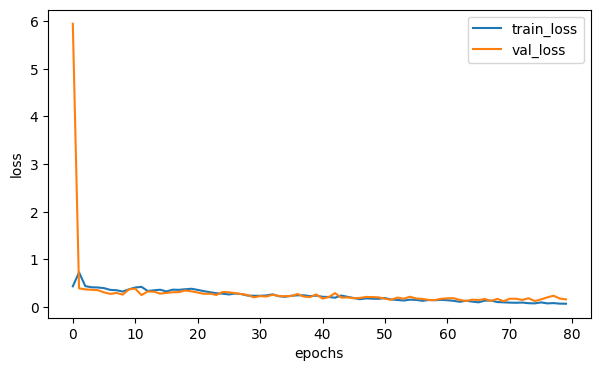


Epoch 081  |  Loss T:0.0712 V:0.1908  |  Accuracy T:0.9704, V:0.9530

Epoch 082  |  Loss T:0.0635 V:0.1502  |  Accuracy T:0.9737, V:0.9583

Epoch 083  |  Loss T:0.0597 V:0.1850  |  Accuracy T:0.9748, V:0.9612

Epoch 084  |  Loss T:0.0573 V:0.1743  |  Accuracy T:0.9761, V:0.9554

Epoch 085  |  Loss T:0.0519 V:0.1537  |  Accuracy T:0.9781, V:0.9582

Epoch 086  |  Loss T:0.0491 V:0.1835  |  Accuracy T:0.9793, V:0.9571

Epoch 087  |  Loss T:0.0478 V:0.1984  |  Accuracy T:0.9799, V:0.9559

Epoch 088  |  Loss T:0.0470 V:0.2088  |  Accuracy T:0.9801, V:0.9563

Epoch 089  |  Loss T:0.0443 V:0.1659  |  Accuracy T:0.9813, V:0.9588

Epoch 090  |  Loss T:0.0417 V:0.1976  |  Accuracy T:0.9824, V:0.9574

Epoch 091  |  Loss T:0.0404 V:0.1868  |  Accuracy T:0.9831, V:0.9575

Epoch 092  |  Loss T:0.0378 V:0.2195  |  Accuracy T:0.9840, V:0.9518

Epoch 093  |  Loss T:0.0367 V:0.1965  |  Accuracy T:0.9845, V:0.9579

Epoch 094  |  Loss T:0.0373 V:0.2168  |  Accuracy T:0.9842, V:0.9540

Epoch 095  |  Loss 

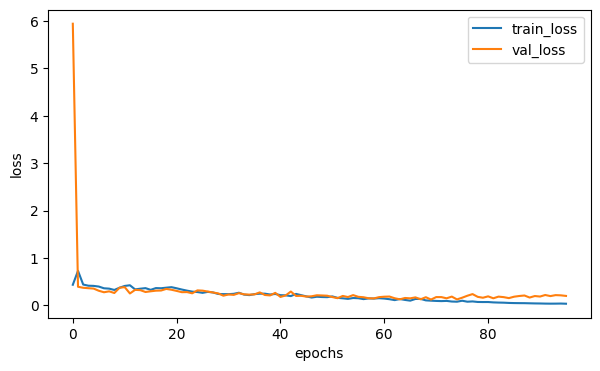


Epoch 097  |  Loss T:0.0332 V:0.2132  |  Accuracy T:0.9858, V:0.9558

Epoch 098  |  Loss T:0.0354 V:0.1825  |  Accuracy T:0.9851, V:0.9577

Epoch 099  |  Loss T:0.0336 V:0.2038  |  Accuracy T:0.9856, V:0.9567

Epoch 100  |  Loss T:0.0345 V:0.2201  |  Accuracy T:0.9853, V:0.9558

Epoch 101  |  Loss T:0.0311 V:0.2268  |  Accuracy T:0.9870, V:0.9591

Epoch 102  |  Loss T:0.0283 V:0.2211  |  Accuracy T:0.9881, V:0.9579

Epoch 103  |  Loss T:0.0265 V:0.2563  |  Accuracy T:0.9888, V:0.9563

Epoch 104  |  Loss T:0.0249 V:0.2700  |  Accuracy T:0.9895, V:0.9574

Epoch 105  |  Loss T:0.0252 V:0.2920  |  Accuracy T:0.9893, V:0.9566

Epoch 106  |  Loss T:0.0292 V:0.2194  |  Accuracy T:0.9876, V:0.9583

Epoch 107  |  Loss T:0.0280 V:0.2297  |  Accuracy T:0.9883, V:0.9574

Epoch 108  |  Loss T:0.0276 V:0.2208  |  Accuracy T:0.9883, V:0.9567

Epoch 109  |  Loss T:0.0269 V:0.2450  |  Accuracy T:0.9888, V:0.9561

Epoch 110  |  Loss T:0.0236 V:0.2513  |  Accuracy T:0.9901, V:0.9575

Epoch 111  |  Loss 

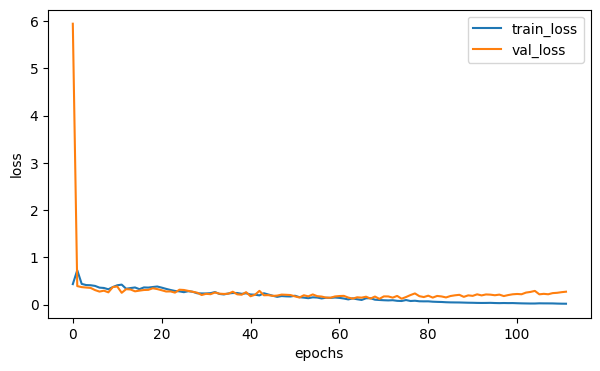


Epoch 113  |  Loss T:0.0231 V:0.2642  |  Accuracy T:0.9902, V:0.9571

Epoch 114  |  Loss T:0.0236 V:0.2600  |  Accuracy T:0.9900, V:0.9571

Epoch 115  |  Loss T:0.0226 V:0.2554  |  Accuracy T:0.9904, V:0.9586

Epoch 116  |  Loss T:0.0200 V:0.2747  |  Accuracy T:0.9915, V:0.9584

Epoch 117  |  Loss T:0.0181 V:0.2887  |  Accuracy T:0.9923, V:0.9590

Epoch 118  |  Loss T:0.0180 V:0.2928  |  Accuracy T:0.9924, V:0.9587

Epoch 119  |  Loss T:0.0180 V:0.2977  |  Accuracy T:0.9924, V:0.9565

Epoch 120  |  Loss T:0.0207 V:0.2889  |  Accuracy T:0.9912, V:0.9592

Epoch 121  |  Loss T:0.0234 V:0.2271  |  Accuracy T:0.9901, V:0.9599

Epoch 122  |  Loss T:0.0201 V:0.2851  |  Accuracy T:0.9916, V:0.9593

Epoch 123  |  Loss T:0.0171 V:0.3112  |  Accuracy T:0.9927, V:0.9595

Epoch 124  |  Loss T:0.0165 V:0.3283  |  Accuracy T:0.9930, V:0.9587

Epoch 125  |  Loss T:0.0160 V:0.3250  |  Accuracy T:0.9932, V:0.9585

Epoch 126  |  Loss T:0.0152 V:0.3313  |  Accuracy T:0.9936, V:0.9583

Epoch 127  |  Loss 

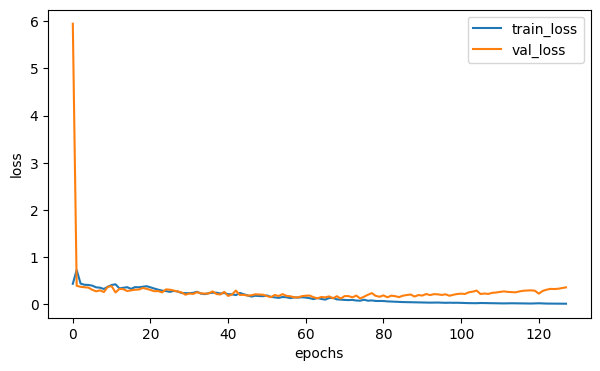

In [56]:
cleanup_models()
unet_model_bce = UNet().to(DEVICE)

bce_mean = nn.BCEWithLogitsLoss(reduction='mean')

history_unet_bce = train(
    train_dataset=train_dataset, 
    val_dataset=val_dataset, 
    model=unet_model_bce, 
    model_name='unet_model_bce',
    epochs=128, 
    batch_size=8, 
    criterion=bce_mean,
    optimizer=torch.optim.AdamW(unet_model_bce.parameters(), lr=5e-4, weight_decay=1e-2), 
    cb_checkpoint=plot_epoch_loss
)

epoch:   0%|          | 0/128 [00:00<?, ?it/s]


Epoch 001  |  Loss T:0.4289 V:0.7626  |  Accuracy T:0.7600, V:0.7300

Epoch 002  |  Loss T:0.3849 V:0.2885  |  Accuracy T:0.7560, V:0.8497

Epoch 003  |  Loss T:0.3233 V:0.2677  |  Accuracy T:0.7770, V:0.7925

Epoch 004  |  Loss T:0.2996 V:0.2374  |  Accuracy T:0.8124, V:0.8283

Epoch 005  |  Loss T:0.2933 V:0.1989  |  Accuracy T:0.8105, V:0.8496

Epoch 006  |  Loss T:0.3128 V:0.2000  |  Accuracy T:0.8199, V:0.8414

Epoch 007  |  Loss T:0.2820 V:0.1901  |  Accuracy T:0.7993, V:0.8324

Epoch 008  |  Loss T:0.2744 V:0.1945  |  Accuracy T:0.7950, V:0.8640

Epoch 009  |  Loss T:0.2791 V:0.1412  |  Accuracy T:0.7925, V:0.8705

Epoch 010  |  Loss T:0.2800 V:0.2100  |  Accuracy T:0.8017, V:0.8363

Epoch 011  |  Loss T:0.2545 V:0.1391  |  Accuracy T:0.8227, V:0.8726

Epoch 012  |  Loss T:0.2580 V:0.1473  |  Accuracy T:0.8426, V:0.8799

Epoch 013  |  Loss T:0.2674 V:0.3415  |  Accuracy T:0.8226, V:0.7127

Epoch 014  |  Loss T:0.2665 V:0.1374  |  Accuracy T:0.8247, V:0.8756

Epoch 015  |  Loss 

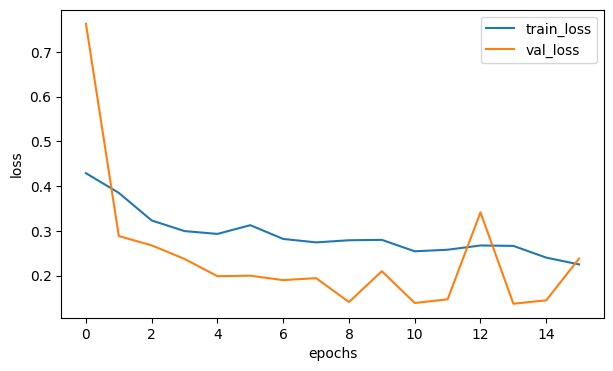


Epoch 017  |  Loss T:0.2927 V:1.0000  |  Accuracy T:0.8153, V:0.7160

Epoch 018  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 019  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 020  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 021  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 022  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 023  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 024  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 025  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 026  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 027  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 028  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 029  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 030  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 031  |  Loss 

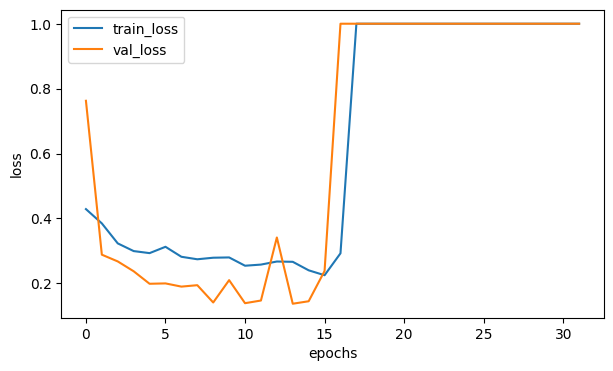


Epoch 033  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 034  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 035  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 036  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 037  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 038  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 039  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 040  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 041  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 042  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 043  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 044  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 045  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 046  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 047  |  Loss 

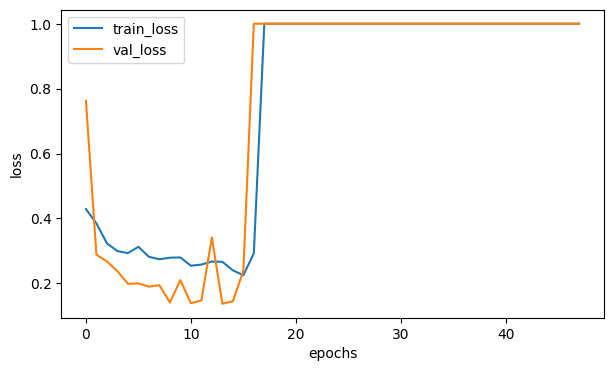


Epoch 049  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 050  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 051  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 052  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 053  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 054  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 055  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 056  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 057  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 058  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 059  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 060  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 061  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 062  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 063  |  Loss 

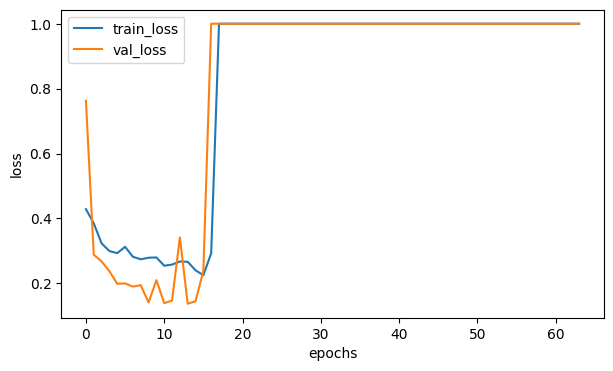


Epoch 065  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 066  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 067  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 068  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 069  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 070  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 071  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 072  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 073  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 074  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 075  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 076  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 077  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 078  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 079  |  Loss 

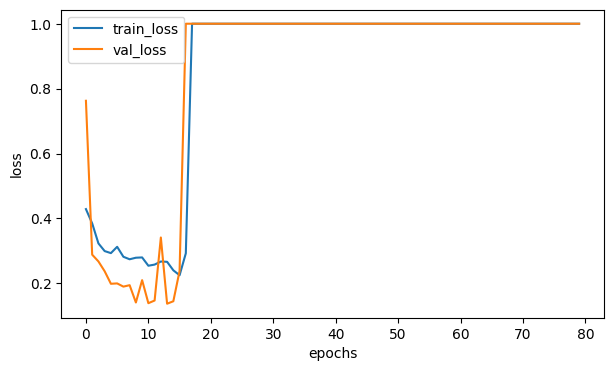


Epoch 081  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 082  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 083  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 084  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 085  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 086  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 087  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 088  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 089  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 090  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 091  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 092  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 093  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 094  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 095  |  Loss 

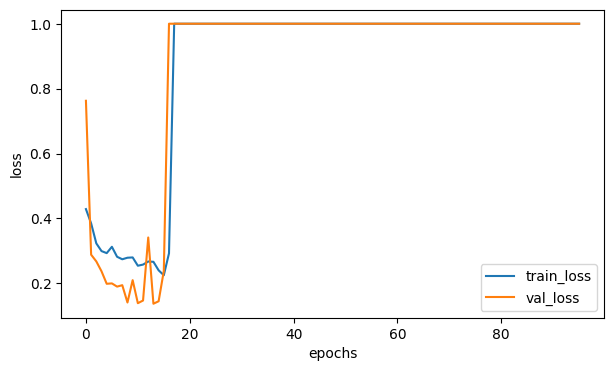


Epoch 097  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 098  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 099  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 100  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 101  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 102  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 103  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 104  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 105  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 106  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 107  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 108  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 109  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 110  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 111  |  Loss 

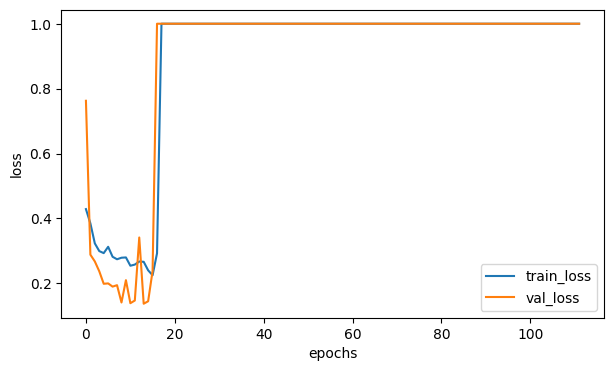


Epoch 113  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 114  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 115  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 116  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 117  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 118  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 119  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 120  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 121  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 122  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 123  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 124  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 125  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 126  |  Loss T:1.0000 V:1.0000  |  Accuracy T:0.6736, V:0.7160

Epoch 127  |  Loss 

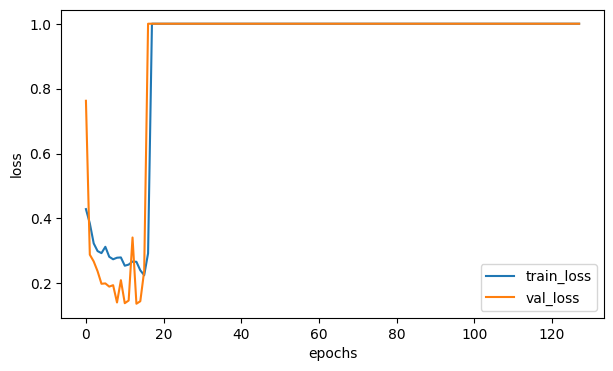

In [57]:
cleanup_models()
unet_model_dice = UNet().to(DEVICE)

history_unet_dice = train(
    train_dataset=train_dataset, 
    val_dataset=val_dataset, 
    model=unet_model_dice, 
    model_name='unet_model_dice',
    epochs=128, 
    batch_size=8, 
    criterion=dice_loss,
    optimizer=torch.optim.AdamW(unet_model_dice.parameters(), lr=5e-4, weight_decay=1e-2), 
    cb_checkpoint=plot_epoch_loss
)

epoch:   0%|          | 0/128 [00:00<?, ?it/s]


Epoch 001  |  Loss T:0.1113 V:0.1300  |  Accuracy T:0.7967, V:0.7327

Epoch 002  |  Loss T:0.1438 V:0.0962  |  Accuracy T:0.7818, V:0.8198

Epoch 003  |  Loss T:0.1112 V:0.0902  |  Accuracy T:0.8216, V:0.8459

Epoch 004  |  Loss T:0.1022 V:0.0807  |  Accuracy T:0.8273, V:0.8615

Epoch 005  |  Loss T:0.1019 V:0.1492  |  Accuracy T:0.8286, V:0.7501

Epoch 006  |  Loss T:0.1145 V:0.0890  |  Accuracy T:0.7901, V:0.8491

Epoch 007  |  Loss T:0.1022 V:0.0846  |  Accuracy T:0.8349, V:0.8605

Epoch 008  |  Loss T:0.1029 V:0.0924  |  Accuracy T:0.8298, V:0.8459

Epoch 009  |  Loss T:0.0977 V:0.0894  |  Accuracy T:0.8309, V:0.8752

Epoch 010  |  Loss T:0.0910 V:0.0922  |  Accuracy T:0.8509, V:0.8528

Epoch 011  |  Loss T:0.1096 V:0.1023  |  Accuracy T:0.8013, V:0.8473

Epoch 012  |  Loss T:0.0990 V:0.0783  |  Accuracy T:0.8395, V:0.8765

Epoch 013  |  Loss T:0.0968 V:0.0846  |  Accuracy T:0.8449, V:0.8717

Epoch 014  |  Loss T:0.0881 V:0.0780  |  Accuracy T:0.8587, V:0.8805

Epoch 015  |  Loss 

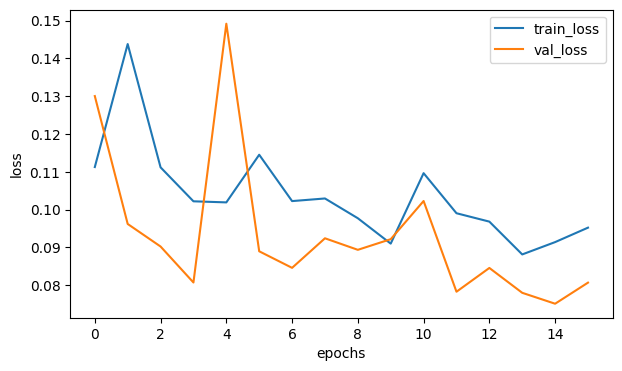


Epoch 017  |  Loss T:0.0895 V:0.0756  |  Accuracy T:0.8603, V:0.8805

Epoch 018  |  Loss T:0.0825 V:0.0704  |  Accuracy T:0.8675, V:0.8903

Epoch 019  |  Loss T:0.0979 V:0.0786  |  Accuracy T:0.8326, V:0.8758

Epoch 020  |  Loss T:0.0922 V:0.0707  |  Accuracy T:0.8565, V:0.9062

Epoch 021  |  Loss T:0.0815 V:0.0803  |  Accuracy T:0.8740, V:0.8757

Epoch 022  |  Loss T:0.0806 V:0.0714  |  Accuracy T:0.8816, V:0.9100

Epoch 023  |  Loss T:0.0773 V:0.0647  |  Accuracy T:0.8870, V:0.9052

Epoch 024  |  Loss T:0.0732 V:0.0678  |  Accuracy T:0.8860, V:0.9023

Epoch 025  |  Loss T:0.0759 V:0.0679  |  Accuracy T:0.8891, V:0.8967

Epoch 026  |  Loss T:0.0762 V:0.0645  |  Accuracy T:0.8827, V:0.9047

Epoch 027  |  Loss T:0.0819 V:0.0850  |  Accuracy T:0.8690, V:0.8545

Epoch 028  |  Loss T:0.0736 V:0.0604  |  Accuracy T:0.8837, V:0.9091

Epoch 029  |  Loss T:0.0721 V:0.0665  |  Accuracy T:0.8922, V:0.9026

Epoch 030  |  Loss T:0.0735 V:0.0622  |  Accuracy T:0.8927, V:0.9110

Epoch 031  |  Loss 

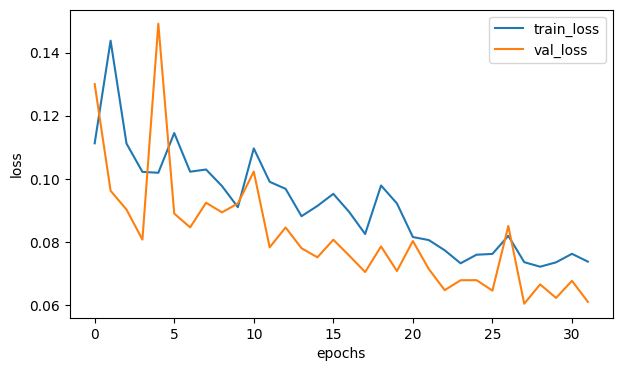


Epoch 033  |  Loss T:0.0654 V:0.0604  |  Accuracy T:0.9008, V:0.9143

Epoch 034  |  Loss T:0.0640 V:0.0590  |  Accuracy T:0.9026, V:0.9160

Epoch 035  |  Loss T:0.0638 V:0.0863  |  Accuracy T:0.9035, V:0.8883

Epoch 036  |  Loss T:0.0730 V:0.0673  |  Accuracy T:0.8900, V:0.9036

Epoch 037  |  Loss T:0.0683 V:0.0588  |  Accuracy T:0.8950, V:0.9166

Epoch 038  |  Loss T:0.0634 V:0.0621  |  Accuracy T:0.9031, V:0.9148

Epoch 039  |  Loss T:0.0603 V:0.0654  |  Accuracy T:0.9104, V:0.9106

Epoch 040  |  Loss T:0.0621 V:0.0586  |  Accuracy T:0.9093, V:0.9183

Epoch 041  |  Loss T:0.0628 V:0.0640  |  Accuracy T:0.9033, V:0.9040

Epoch 042  |  Loss T:0.0689 V:0.0621  |  Accuracy T:0.9025, V:0.9124

Epoch 043  |  Loss T:0.0609 V:0.0616  |  Accuracy T:0.9088, V:0.9213

Epoch 044  |  Loss T:0.0595 V:0.0598  |  Accuracy T:0.9127, V:0.9151

Epoch 045  |  Loss T:0.0717 V:0.0707  |  Accuracy T:0.8910, V:0.8918

Epoch 046  |  Loss T:0.0633 V:0.0707  |  Accuracy T:0.9044, V:0.9062

Epoch 047  |  Loss 

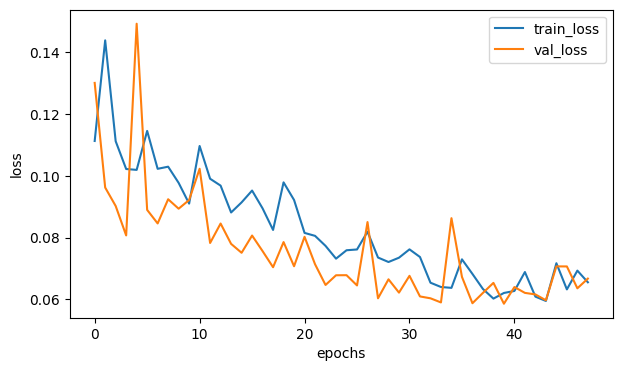


Epoch 049  |  Loss T:0.0706 V:0.0621  |  Accuracy T:0.8919, V:0.9139

Epoch 050  |  Loss T:0.0661 V:0.0589  |  Accuracy T:0.8993, V:0.9203

Epoch 051  |  Loss T:0.0647 V:0.0576  |  Accuracy T:0.9059, V:0.9212

Epoch 052  |  Loss T:0.0577 V:0.0588  |  Accuracy T:0.9145, V:0.9215

Epoch 053  |  Loss T:0.0607 V:0.0703  |  Accuracy T:0.9088, V:0.9029

Epoch 054  |  Loss T:0.0581 V:0.0588  |  Accuracy T:0.9125, V:0.9278

Epoch 055  |  Loss T:0.0549 V:0.0551  |  Accuracy T:0.9205, V:0.9329

Epoch 056  |  Loss T:0.0549 V:0.0749  |  Accuracy T:0.9207, V:0.9106

Epoch 057  |  Loss T:0.0611 V:0.0525  |  Accuracy T:0.9161, V:0.9285

Epoch 058  |  Loss T:0.0556 V:0.0790  |  Accuracy T:0.9216, V:0.8944

Epoch 059  |  Loss T:0.0580 V:0.0562  |  Accuracy T:0.9149, V:0.9256

Epoch 060  |  Loss T:0.0543 V:0.0558  |  Accuracy T:0.9192, V:0.9344

Epoch 061  |  Loss T:0.0501 V:0.0570  |  Accuracy T:0.9268, V:0.9266

Epoch 062  |  Loss T:0.0491 V:0.0507  |  Accuracy T:0.9287, V:0.9334

Epoch 063  |  Loss 

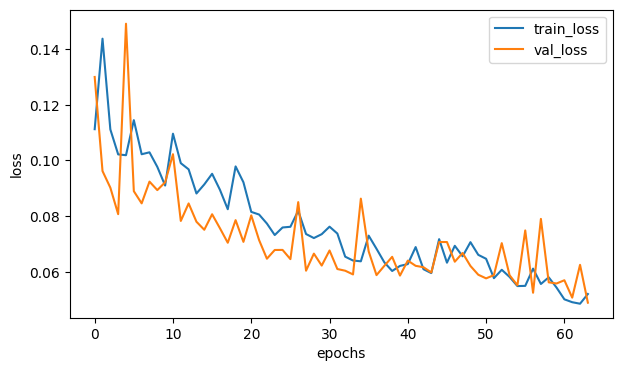


Epoch 065  |  Loss T:0.0502 V:0.0460  |  Accuracy T:0.9294, V:0.9404

Epoch 066  |  Loss T:0.0468 V:0.0476  |  Accuracy T:0.9323, V:0.9426

Epoch 067  |  Loss T:0.0457 V:0.0456  |  Accuracy T:0.9350, V:0.9416

Epoch 068  |  Loss T:0.0432 V:0.0490  |  Accuracy T:0.9360, V:0.9415

Epoch 069  |  Loss T:0.0474 V:0.0536  |  Accuracy T:0.9296, V:0.9314

Epoch 070  |  Loss T:0.0497 V:0.0583  |  Accuracy T:0.9260, V:0.9258

Epoch 071  |  Loss T:0.0461 V:0.0456  |  Accuracy T:0.9290, V:0.9421

Epoch 072  |  Loss T:0.0482 V:0.0430  |  Accuracy T:0.9328, V:0.9399

Epoch 073  |  Loss T:0.0484 V:0.0525  |  Accuracy T:0.9297, V:0.9352

Epoch 074  |  Loss T:0.0424 V:0.0518  |  Accuracy T:0.9380, V:0.9392

Epoch 075  |  Loss T:0.0436 V:0.0575  |  Accuracy T:0.9364, V:0.9359

Epoch 076  |  Loss T:0.0438 V:0.0512  |  Accuracy T:0.9350, V:0.9391

Epoch 077  |  Loss T:0.0427 V:0.0453  |  Accuracy T:0.9378, V:0.9477

Epoch 078  |  Loss T:0.0433 V:0.0595  |  Accuracy T:0.9357, V:0.9265

Epoch 079  |  Loss 

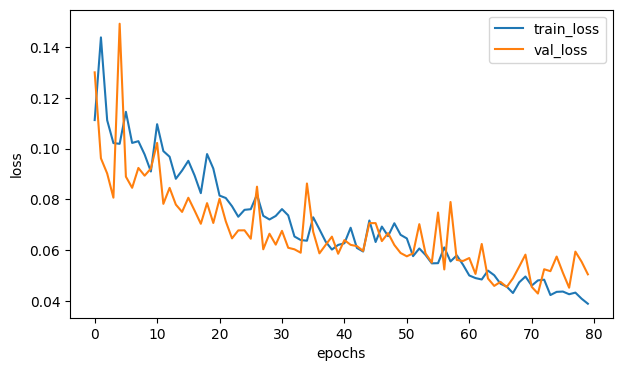


Epoch 081  |  Loss T:0.0383 V:0.0492  |  Accuracy T:0.9415, V:0.9451

Epoch 082  |  Loss T:0.0388 V:0.0518  |  Accuracy T:0.9411, V:0.9426

Epoch 083  |  Loss T:0.0417 V:0.0430  |  Accuracy T:0.9395, V:0.9453

Epoch 084  |  Loss T:0.0437 V:0.0552  |  Accuracy T:0.9333, V:0.9346

Epoch 085  |  Loss T:0.0411 V:0.0411  |  Accuracy T:0.9384, V:0.9428

Epoch 086  |  Loss T:0.0369 V:0.0417  |  Accuracy T:0.9439, V:0.9501

Epoch 087  |  Loss T:0.0385 V:0.0432  |  Accuracy T:0.9411, V:0.9454

Epoch 088  |  Loss T:0.0363 V:0.0391  |  Accuracy T:0.9452, V:0.9527

Epoch 089  |  Loss T:0.0336 V:0.0478  |  Accuracy T:0.9498, V:0.9467

Epoch 090  |  Loss T:0.0330 V:0.0392  |  Accuracy T:0.9501, V:0.9495

Epoch 091  |  Loss T:0.0391 V:0.0398  |  Accuracy T:0.9435, V:0.9503

Epoch 092  |  Loss T:0.0377 V:0.0409  |  Accuracy T:0.9437, V:0.9488

Epoch 093  |  Loss T:0.0366 V:0.0432  |  Accuracy T:0.9449, V:0.9481

Epoch 094  |  Loss T:0.0325 V:0.0408  |  Accuracy T:0.9511, V:0.9510

Epoch 095  |  Loss 

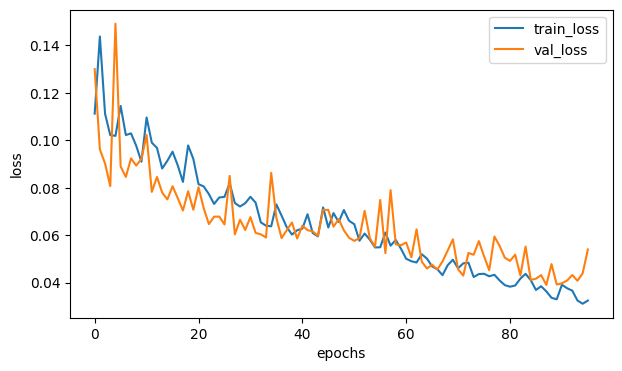


Epoch 097  |  Loss T:0.0348 V:0.0477  |  Accuracy T:0.9489, V:0.9327

Epoch 098  |  Loss T:0.0324 V:0.0489  |  Accuracy T:0.9517, V:0.9374

Epoch 099  |  Loss T:0.0335 V:0.0363  |  Accuracy T:0.9486, V:0.9556

Epoch 100  |  Loss T:0.0306 V:0.0382  |  Accuracy T:0.9526, V:0.9568

Epoch 101  |  Loss T:0.0272 V:0.0538  |  Accuracy T:0.9573, V:0.9498

Epoch 102  |  Loss T:0.0270 V:0.0407  |  Accuracy T:0.9575, V:0.9480

Epoch 103  |  Loss T:0.0269 V:0.0607  |  Accuracy T:0.9571, V:0.9505

Epoch 104  |  Loss T:0.0274 V:0.0548  |  Accuracy T:0.9593, V:0.9503

Epoch 105  |  Loss T:0.0258 V:0.0440  |  Accuracy T:0.9598, V:0.9529

Epoch 106  |  Loss T:0.0233 V:0.0617  |  Accuracy T:0.9631, V:0.9473

Epoch 107  |  Loss T:0.0232 V:0.0655  |  Accuracy T:0.9638, V:0.9459

Epoch 108  |  Loss T:0.0279 V:0.0450  |  Accuracy T:0.9556, V:0.9419

Epoch 109  |  Loss T:0.0257 V:0.0494  |  Accuracy T:0.9597, V:0.9540

Epoch 110  |  Loss T:0.0375 V:0.0365  |  Accuracy T:0.9408, V:0.9501

Epoch 111  |  Loss 

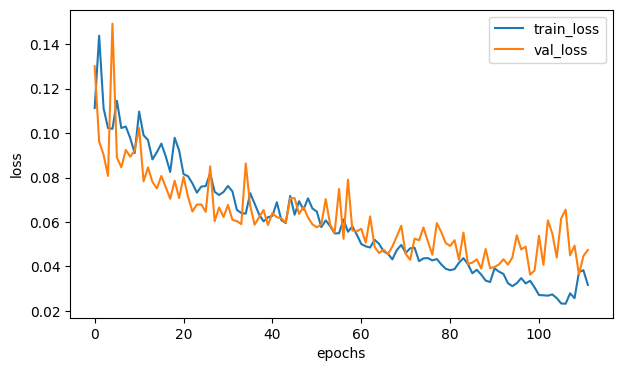


Epoch 113  |  Loss T:0.0268 V:0.0425  |  Accuracy T:0.9580, V:0.9543

Epoch 114  |  Loss T:0.0241 V:0.0544  |  Accuracy T:0.9628, V:0.9451

Epoch 115  |  Loss T:0.0247 V:0.0450  |  Accuracy T:0.9610, V:0.9550

Epoch 116  |  Loss T:0.0236 V:0.0424  |  Accuracy T:0.9634, V:0.9590

Epoch 117  |  Loss T:0.0210 V:0.0549  |  Accuracy T:0.9670, V:0.9577

Epoch 118  |  Loss T:0.0189 V:0.0579  |  Accuracy T:0.9697, V:0.9582

Epoch 119  |  Loss T:0.0176 V:0.0644  |  Accuracy T:0.9722, V:0.9576

Epoch 120  |  Loss T:0.0187 V:0.0762  |  Accuracy T:0.9704, V:0.9513

Epoch 121  |  Loss T:0.0175 V:0.0642  |  Accuracy T:0.9717, V:0.9560

Epoch 122  |  Loss T:0.0198 V:0.0465  |  Accuracy T:0.9685, V:0.9509

Epoch 123  |  Loss T:0.0197 V:0.0518  |  Accuracy T:0.9693, V:0.9547

Epoch 124  |  Loss T:0.0191 V:0.0658  |  Accuracy T:0.9697, V:0.9505

Epoch 125  |  Loss T:0.0178 V:0.0800  |  Accuracy T:0.9716, V:0.9481

Epoch 126  |  Loss T:0.0187 V:0.0497  |  Accuracy T:0.9707, V:0.9552

Epoch 127  |  Loss 

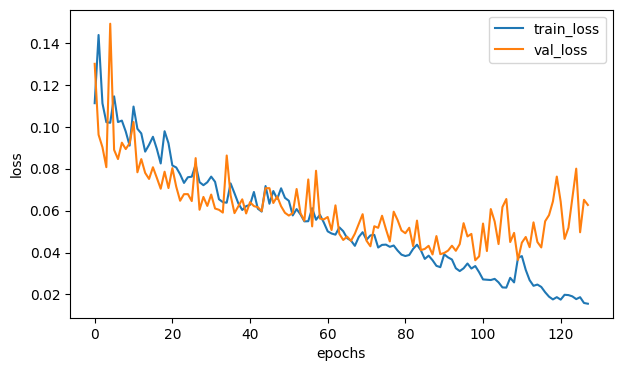

In [58]:
cleanup_models()
unet_model_focal = UNet().to(DEVICE)

history_unet_focal = train(
    train_dataset=train_dataset, 
    val_dataset=val_dataset, 
    model=unet_model_focal, 
    model_name='unet_model_focal',
    epochs=128, 
    batch_size=8, 
    criterion=focal_loss,
    optimizer=torch.optim.AdamW(unet_model_focal.parameters(), lr=5e-4, weight_decay=1e-2), 
    cb_checkpoint=plot_epoch_loss
)

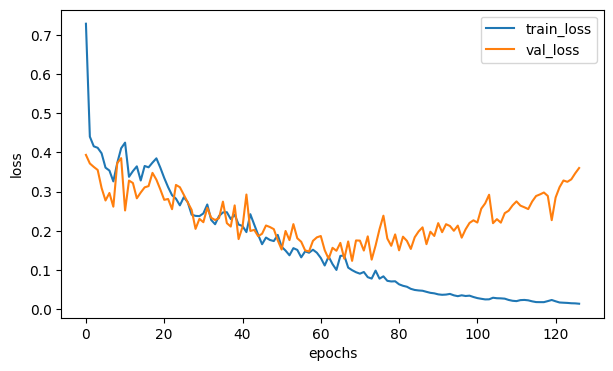

In [66]:
plot_epoch_loss(history_unet_bce[1:])

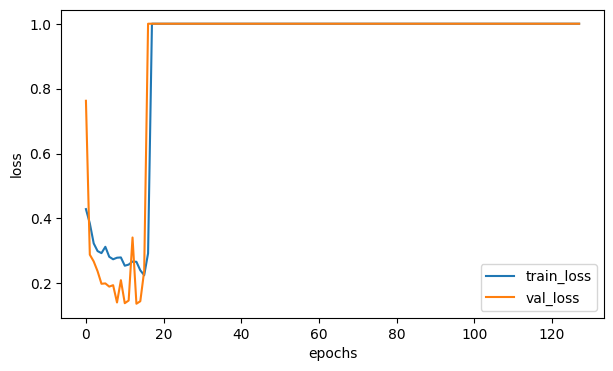

In [64]:
plot_epoch_loss(history_unet_dice)

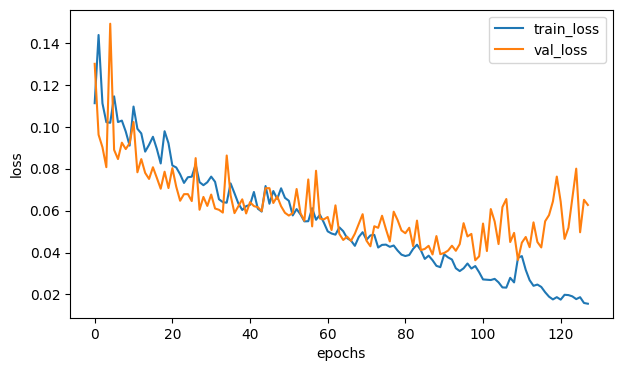

In [65]:
plot_epoch_loss(history_unet_focal)

In [72]:
cleanup_models()
test_model_checkpoint("best_unet_model_bce.pth", model=UNet, criterion=bce_mean)
cleanup_models()
test_model_checkpoint("best_unet_model_dice.pth", model=UNet, criterion=bce_mean)
cleanup_models()
test_model_checkpoint("best_unet_model_focal.pth", model=UNet, criterion=bce_mean)
cleanup_models()

C:\Users\efimplotnikov\AppData\Local\Temp\ipykernel_19492\2410446969.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(cp, map_location=DEVICE)



----- ----- best_unet_model_bce.pth ----- -----
Epoch: 69
Elapsed time: 838.9333100318909 sec.
Test loss: 0.060734521597623825, test accuracy: 0.3258104960123698
Test IoU: 0.9343395829200745

----- ----- best_unet_model_dice.pth ----- -----
Epoch: 13
Elapsed time: 180.34021878242493 sec.
Test loss: 34.395137786865234, test accuracy: 0.2713617960611979
Test IoU: 0.5793858170509338

----- ----- best_unet_model_focal.pth ----- -----
Epoch: 98
Elapsed time: 1214.876066684723 sec.
Test loss: 0.16557364165782928, test accuracy: 0.320843760172526
Test IoU: 0.8943540453910828
